# Notebook 03 - Organic Product Tribe Discovery Lab

This notebook is the experiment lab for finding actionable organic customer tribes from products bought. The aim is not to prove that one algorithm is best in isolation; it is to compare representations and clustering assumptions until we find segments that are product-led, stable, large enough to activate, and commercially readable.

**Important:** stored outputs may reflect an earlier run. After changing `configs/dev.yaml`, restart the kernel and rerun from Section 3.0 so `src.config` reloads the active experiment settings.

## Table of Contents
- [3.0 Research Design, Setup and Run Controls](#30-research-design-setup-and-run-controls)
- [3.1 Product Embedding Pipeline](#31-product-embedding-pipeline)
- [3.2 Customer Vector Construction](#32-customer-vector-construction)
- [3.3 Representation Comparison: UMAP vs PCA](#33-dimensionality-reduction)
- [3.4 Clustering, Profiling and Tribe Selection](#34-clustering-experiments)
- [3.5 Selection Log and Next Experiments](#35-selection-log-and-next-experiments)

<a id="30-research-design-setup-and-run-controls"></a>
## 3.0 Research Design, Setup and Run Controls

Define what a useful product tribe means, then select mode, import dependencies, validate upstream artifacts from Notebook 02, and configure rerun controls.

### 3.0.1 Research Question and Decision Rules

**Research question:** can we discover organic customer tribes from the products people buy, such as baby households, pet owners, health-conscious shoppers, protein buyers, free-from shoppers, international-food shoppers, or other patterns we did not predefine?

**Current baseline:** product-only clustering. Promo, store, spend, visit frequency, and basket KPIs are used for profiling after clustering, not as clustering inputs. This prevents easy but strategically weak splits such as store-format clusters or promo-sensitivity clusters.

**Representation tests:**
- Product embeddings test whether basket co-purchase behavior creates meaningful product similarity.
- Enhanced Item2Vec customer vectors test whether normalised product embeddings plus log-recency weighting improve profiles.
- TF-IDF + SVD vectors test whether direct customer-product affinities are cleaner than averaged embeddings.
- Product-share vectors add sector, product-type, and product-theme composition signals. Store shares are kept as an explicit non-baseline ablation.
- Hybrid vectors concatenate those product-led blocks for the primary experiment.
- Mean customer vectors test whether simpler long-run product taste is cleaner.

**Dimensionality tests:**
- PCA is the linear baseline: fast, stable, and easy to challenge.
- UMAP is the nonlinear candidate: useful if customer product behavior has curved, local structure.

**Clustering tests:**
- HDBSCAN is the primary method required by the brief: it searches for natural density groups and can mark ambiguous customers as noise.
- HDBSCAN + nearest-tribe assignment is the operational variant: density-discovered core tribes remain primary, while noise customers receive a nearest-core label and a confidence flag.
- K-Means is retained only as a discouraged-but-useful benchmark because it imposes a fixed K and spherical territories.

**Selection rule:** do not choose from silhouette alone. Prefer an HDBSCAN-derived solution if it has readable product/theme lifts and acceptable assignment confidence. Use K-Means only as a benchmark unless HDBSCAN-derived profiles fail commercially.

In [1]:
# -- 3.0 MASTER RUN CONTROLS -----------------------------------------------
# This is the ONLY cell you need to change before a run.
#
# Use "auto" in configs/base.yaml to benchmark candidates and select winners.
# Use concrete values to lock a phase for a reproducible rerun.
# -----------------------------------------------------------------------
import os, sys, importlib
from pathlib import Path

_root = next(
    p for p in [Path.cwd(), Path.cwd().parent]
    if (p / 'src' / 'config.py').exists()
)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

os.environ['CARREFOUR_MODE'] = 'dev'   # <-- change to 'prod' for final run

import src.config
importlib.reload(src.config)
from src.config import (
    MODE, DATA_PROCESSED, MODELS, OUTPUTS,
    PIPELINE_SELECTION_MODE,
    PIPELINE_VECTOR_SOURCE,
    PIPELINE_REDUCER,
    PIPELINE_CLUSTERER,
    PIPELINE_FALLBACK_VECTOR_SOURCE,
    PIPELINE_FALLBACK_REDUCER,
    PIPELINE_FALLBACK_CLUSTERER,
    VECTOR_SOURCE_CANDIDATES,
    REDUCER_CANDIDATES,
    CLUSTERER_CANDIDATES,
    MODEL_SELECTION_TARGET_TRIBE_COUNT,
    TARGET_KMEANS_K as CONFIG_TARGET_KMEANS_K,
)

_is_dev = (MODE == 'dev')

FORCE_EMBEDDINGS  = False
FORCE_VECTORS     = False
FORCE_UMAP        = False
FORCE_CLUSTERING  = False

VECTOR_SOURCE = PIPELINE_VECTOR_SOURCE
REDUCER       = PIPELINE_REDUCER
CLUSTERER     = PIPELINE_CLUSTERER

VECTOR_SOURCE_BENCHMARKS = list(VECTOR_SOURCE_CANDIDATES)
REDUCER_BENCHMARKS       = list(REDUCER_CANDIDATES)
CLUSTERER_BENCHMARKS     = list(CLUSTERER_CANDIDATES)
TARGET_TRIBE_COUNT       = MODEL_SELECTION_TARGET_TRIBE_COUNT
TARGET_KMEANS_K          = CONFIG_TARGET_KMEANS_K

RUN_VECTOR_SOURCE_BENCHMARK = _is_dev or VECTOR_SOURCE == 'auto'
RUN_REDUCER_BENCHMARK       = _is_dev or REDUCER == 'auto'
RUN_N_NEIGHBORS_SENSITIVITY = False
RUN_HDBSCAN_GRID_SEARCH     = False
RUN_KMEANS_BASELINES        = _is_dev or CLUSTERER == 'auto' or 'kmeans' in CLUSTERER_BENCHMARKS

FORCE_VECTOR_SOURCE_BENCHMARK = False

print(f'Mode          : {MODE.upper()}')
print(f'Data          : {DATA_PROCESSED}')
print(f'Selection mode: {PIPELINE_SELECTION_MODE}')
print(f'Vector source : requested={VECTOR_SOURCE} fallback={PIPELINE_FALLBACK_VECTOR_SOURCE} candidates={VECTOR_SOURCE_BENCHMARKS}')
print(f'Reducer       : requested={REDUCER} fallback={PIPELINE_FALLBACK_REDUCER} candidates={REDUCER_BENCHMARKS}')
print(f'Clusterer     : requested={CLUSTERER} fallback={PIPELINE_FALLBACK_CLUSTERER} candidates={CLUSTERER_BENCHMARKS}')
print(f'Target tribes : {TARGET_TRIBE_COUNT} | K-Means target K: {TARGET_KMEANS_K}')
print(f'Force flags   : embeddings={FORCE_EMBEDDINGS}  vectors={FORCE_VECTORS}  '
      f'umap={FORCE_UMAP}  clustering={FORCE_CLUSTERING}')
print(f'Run sections  : vector_benchmark={RUN_VECTOR_SOURCE_BENCHMARK}  '
      f'reducer_benchmark={RUN_REDUCER_BENCHMARK}  '
      f'sensitivity={RUN_N_NEIGHBORS_SENSITIVITY}  '
      f'hdbscan_grid={RUN_HDBSCAN_GRID_SEARCH}  '
      f'kmeans_grid={RUN_KMEANS_BASELINES}')

Mode          : DEV
Data          : C:\Users\sebog\proyectos\carrefour_capstone\data\dev
Selection mode: auto
Vector source : requested=auto fallback=hybrid candidates=['item2vec', 'tfidf_svd', 'hybrid']
Reducer       : requested=auto fallback=umap candidates=['umap', 'pca']
Clusterer     : requested=auto fallback=hdbscan_assigned candidates=['hdbscan_assigned', 'kmeans']
Target tribes : 15 | K-Means target K: 15
Force flags   : embeddings=False  vectors=False  umap=False  clustering=False
Run sections  : vector_benchmark=True  reducer_benchmark=True  sensitivity=False  hdbscan_grid=False  kmeans_grid=True


In [2]:
import sys, warnings, logging, time
from pathlib import Path

_root = next(
    (p for p in [Path.cwd(), Path.cwd().parent] if (p / 'src' / 'config.py').exists()),
    None,
)
if _root is None:
    raise RuntimeError('Cannot locate project root. Launch from the repo root.')
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
warnings.filterwarnings("ignore")
logging.basicConfig(format="%(asctime)s %(levelname)s %(message)s",
                    level=logging.INFO, datefmt="%H:%M:%S")

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from src.config import ROOT, MODE, DATA_PROCESSED, OUTPUTS

OUTPUTS.mkdir(parents=True, exist_ok=True)

# -- Confirm Notebook 2 outputs exist before proceeding ----------------------
# quality_report.json and customer_kpis.parquet are prod-only artifacts
# (always in data/processed/). df_combined.parquet is mode-specific:
# data/dev/ in dev mode, data/processed/ in prod mode.
PROD_PROCESSED = ROOT / "data" / "processed"

required = {
    DATA_PROCESSED / "df_combined.parquet"  : "Section 3 (02_pre-analysis.ipynb)",
    PROD_PROCESSED / "customer_kpis.parquet": "Section 4.1 (02_pre-analysis.ipynb)",
    PROD_PROCESSED / "quality_report.json"  : "Section 2 (02_pre-analysis.ipynb)",
}
all_ok = True
for fpath, source in required.items():
    if fpath.exists():
        size = fpath.stat().st_size
        unit = "GB" if size > 1e9 else "MB"
        size_disp = size / (1024**3 if unit == "GB" else 1024**2)
        print(f"  OK  {fpath.name} ({size_disp:.1f} {unit})  [{fpath.parent.name}/]")
    else:
        print(f"  MISSING  {fpath}  <- run {source} first")
        all_ok = False

if not all_ok:
    raise FileNotFoundError(
        "One or more Notebook 2 outputs are missing. "
        "Run 02_pre-analysis.ipynb in prod mode first."
    )

print(f"\nAll outputs confirmed. Running in {MODE.upper()} mode — ready to proceed.")

  OK  df_combined.parquet (96.3 MB)  [dev/]
  OK  customer_kpis.parquet (113.6 MB)  [processed/]
  OK  quality_report.json (0.0 MB)  [processed/]

All outputs confirmed. Running in DEV mode — ready to proceed.


<a id="31-product-embedding-pipeline"></a>
## 3.1 Product Embedding Pipeline

Build Item2Vec product embeddings from basket co-occurrence. These embeddings represent products by the company they keep in real customer baskets.

In [3]:
# -- 3.1 Phase 1 Imports -------------------------------------------------
# The mode selector (Section 3.0) must have run before this cell.
# Starting from here defaults to MODE=prod if Section 3.0 was skipped.
import time

from src.embeddings import build_basket_sentences, build_product_embeddings, train_word2vec, save_embeddings, sanity_check
from src.product_filtering import build_product_popularity, popularity_filter_summary
from src.config import (
    DATA_PROCESSED,
    MODELS,
    OUTPUTS,
    PRODUCT_EMBEDDING_METHOD,
    PRODUCT_EMBEDDING_CANDIDATES,
    PRODUCT_IDF_WEIGHTING_ENABLED,
    PRODUCT_POPULARITY_ENABLED,
)

# Picks up FORCE_EMBEDDINGS from Section 3.0 if it was set; falls back to True.
FORCE_EMBEDDINGS = globals().get('FORCE_EMBEDDINGS', True)

# Re-attach product master if this session started from Section 3.1
if 'df_articles' not in vars():
    from src.data_loader import load_maestra_articulos
    df_articles = load_maestra_articulos()
    print(f'Loaded df_articles: {len(df_articles):,} rows')
else:
    print(f'df_articles in session: {len(df_articles):,} rows')

print('Phase 1 imports ready.')
print(f'Product embedding method: {PRODUCT_EMBEDDING_METHOD} | candidates={PRODUCT_EMBEDDING_CANDIDATES}')
print(f'FORCE_EMBEDDINGS = {FORCE_EMBEDDINGS}')

Loaded df_articles: 893,944 rows
Phase 1 imports ready.
Product embedding method: word2vec | candidates=['word2vec']
FORCE_EMBEDDINGS = False


### 3.1.1 Build Basket Sentences

Convert each ticket into a product sequence so Word2Vec can learn product context from co-purchases.

13:38:49 INFO Product popularity cache hit - product_popularity.parquet


Product popularity filter: enabled=True,  removed=1/78,011 products  (0.00%),  IDF weighting=True


idarticu,desc_larga_articulo,desc_sector,n_baskets,basket_share_pct,n_customers,customer_share_pct,idf_weight,is_popularity_removed
i64,str,str,u32,f32,u32,f32,f32,bool
632052,"""BOLSA 48X60CM 100% PLASTICO RE…","""BAZAR""",159109,20.17,28769,65.379997,0.42,true
35923,"""FRESON TARRINA 500 GRAMOS""","""PROD. FRESCOS TRADIC""",48213,6.11,17117,38.900002,0.94,false
216537,"""BARRA DE PAN CARREFOUR 250G""","""PROD. FRESCOS TRADIC""",50085,6.35,13556,30.809999,1.18,false
35834,"""BANANA GRANEL""","""PROD. FRESCOS TRADIC""",51316,6.51,13515,30.719999,1.18,false
431967,"""CALABACIN CARREFOUR GRANEL""","""PROD. FRESCOS TRADIC""",19565,2.48,9043,20.549999,1.58,false
…,…,…,…,…,…,…,…,…
89124,"""AGUACATE CDC 14/16 GRANEL""","""PROD. FRESCOS TRADIC""",10309,1.31,5066,11.51,2.16,false
394510,"""PERA CONFERENCIA CARREFOUR …","""PROD. FRESCOS TRADIC""",13655,1.73,4983,11.32,2.18,false
231388,"""HUEVOS MORENOS L DOCENA …","""PROD. FRESCOS TRADIC""",11239,1.42,4857,11.04,2.2,false


13:38:49 INFO Cache hit — 701,896 baskets in basket_sentences.parquet


Baskets built           :      701,896
Median items per basket :    6.0
Mean items per basket   :   10.4
p25 / p75               : 3 / 13
p99 (large baskets)     : 54
Single-item baskets     : 0.0%


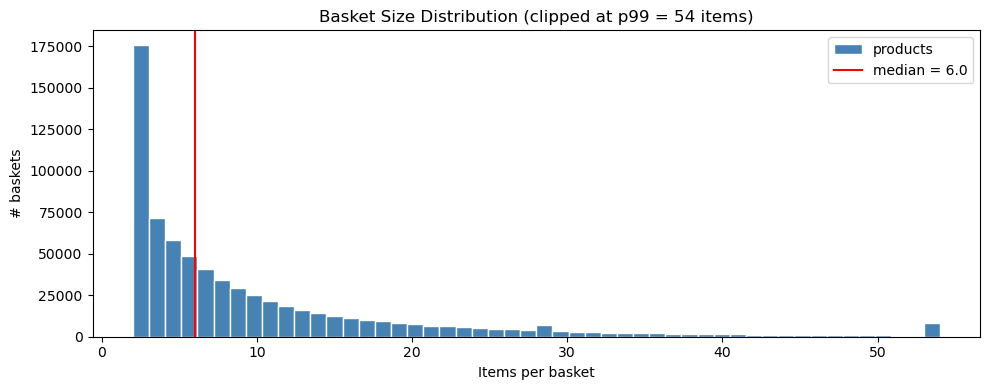

In [4]:
# 3.1.1 Build product popularity diagnostics and popularity-filtered basket sentences
product_popularity = build_product_popularity(force=FORCE_EMBEDDINGS)
_pop_summary = popularity_filter_summary(product_popularity)
print(
    "Product popularity filter:",
    f"enabled={bool(_pop_summary['enabled'])}, ",
    f"removed={_pop_summary['n_removed']:,}/{_pop_summary['n_products']:,} products ",
    f"({_pop_summary['removed_pct']:.2f}%), ",
    f"IDF weighting={PRODUCT_IDF_WEIGHTING_ENABLED}",
)

_pop_view = (
    product_popularity
    .join(df_articles.select(["idarticu", "desc_larga_articulo", "desc_sector"]), on="idarticu", how="left")
    .sort(["customer_share", "basket_share"], descending=True)
    .select([
        "idarticu",
        "desc_larga_articulo",
        "desc_sector",
        pl.col("n_baskets"),
        (pl.col("basket_share") * 100).round(2).alias("basket_share_pct"),
        pl.col("n_customers"),
        (pl.col("customer_share") * 100).round(2).alias("customer_share_pct"),
        pl.col("idf_weight").round(2),
        "is_popularity_removed",
    ])
    .head(30)
)
display(_pop_view)

basket_path = build_basket_sentences(
    popularity=product_popularity,
    force=FORCE_EMBEDDINGS,
)
baskets = pl.read_parquet(basket_path)   # load into memory for stats

# Basket size distribution
basket_sizes = baskets["products"].list.len()   # Polars Series of ints

p99_size = int(basket_sizes.quantile(0.99))

size_stats = {
    "n_baskets":       len(baskets),
    "median_size":     float(basket_sizes.median()),
    "mean_size":       float(basket_sizes.mean()),
    "p25":             float(basket_sizes.quantile(0.25)),
    "p75":             float(basket_sizes.quantile(0.75)),
    "p99":             float(p99_size),
    "single_item_pct": float((basket_sizes == 1).mean() * 100),
}

print(f"Baskets built           : {size_stats['n_baskets']:>12,}")
print(f"Median items per basket : {size_stats['median_size']:>6.1f}")
print(f"Mean items per basket   : {size_stats['mean_size']:>6.1f}")
print(f"p25 / p75               : {size_stats['p25']:.0f} / {size_stats['p75']:.0f}")
print(f"p99 (large baskets)     : {size_stats['p99']:.0f}")
print(f"Single-item baskets     : {size_stats['single_item_pct']:.1f}%")

fig, ax = plt.subplots(figsize=(10, 4))
# Polars clip uses upper_bound= (not upper= like pandas)
(
    basket_sizes
    .clip(upper_bound=p99_size)
    .to_pandas()
    .plot.hist(bins=50, ax=ax, color="steelblue", edgecolor="white",
               title=f"Basket Size Distribution (clipped at p99 = {p99_size} items)")
)
ax.set_xlabel("Items per basket")
ax.set_ylabel("# baskets")
ax.axvline(size_stats["median_size"], color="red", lw=1.5,
           label=f"median = {size_stats['median_size']:.1f}")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS / "embedding_basket_sizes.png", dpi=120)
plt.show()

del baskets, basket_sizes   # free RAM before training

### 3.1.2 Train Configured Product Embedding Model

Train product embeddings from basket sentences. The only implemented Phase 1 embedding model is currently `word2vec`, configured in `configs/base.yaml -> product_embeddings.method`.

**Why `window=10` (raised from the NLP default of 5)**

Grocery baskets have no natural word order. Products within a basket are sorted by `idarticu` (an arbitrary integer key), so there is no linguistic sequence. With `window=5`, a product only learns from the 5 nearest neighbours in the sorted ID list. In a basket of 20 products that means roughly 50 % of within-basket co-purchase pairs are missed; in larger baskets the coverage drops below 35 %.

Item2Vec research treats the entire basket as the context window, or at minimum uses a window large enough to ensure all products share at least one context step. `window=10` is a practical compromise that captures the majority of co-purchase pairs without over-weighting products with adjacent IDs. This is validated in the sanity check (Section 3.1.4): commercial neighbours should appear as top-5 most-similar products.

`sg=1` (skip-gram) is kept as the configured default. Change `word2vec.sg` to test CBOW as a Phase 1 ablation.

In [5]:
# 3.1.2 Train configured product embedding model
# First run: ~20-40 min (prod) / ~5-15 min (dev). Subsequent runs: cache hit.
_t0 = time.time()

if PRODUCT_EMBEDDING_METHOD != 'word2vec':
    raise NotImplementedError(
        f'Configured product embedding method {PRODUCT_EMBEDDING_METHOD!r} is not implemented yet.'
    )

w2v_model = train_word2vec(
    basket_path=basket_path,
    force=FORCE_EMBEDDINGS,
)

_elapsed = time.time() - _t0
print(f'{PRODUCT_EMBEDDING_METHOD} training complete in {_elapsed/60:.1f} min')
print(f'Vocabulary  : {len(w2v_model.wv):,} products')
print(f'Vector size : {w2v_model.wv.vector_size}')
print(f'Skip-gram   : {bool(w2v_model.sg)}')

13:38:50 INFO Loading basket sentences into memory (one-time) ...
13:38:50 INFO   701,896 baskets loaded
13:38:50 INFO Training Word2Vec | 701,896 baskets | vector_size=100  window=10  min_count=3  epochs=5  sg=1  workers=1
13:38:50 INFO collecting all words and their counts
13:38:50 INFO PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
13:38:50 INFO PROGRESS: at sentence #10000, processed 103982 words, keeping 23007 word types
13:38:50 INFO PROGRESS: at sentence #20000, processed 202792 words, keeping 30592 word types
13:38:50 INFO PROGRESS: at sentence #30000, processed 315112 words, keeping 34681 word types
13:38:50 INFO PROGRESS: at sentence #40000, processed 418225 words, keeping 37398 word types
13:38:50 INFO PROGRESS: at sentence #50000, processed 526662 words, keeping 39735 word types
13:38:50 INFO PROGRESS: at sentence #60000, processed 634724 words, keeping 41708 word types
13:38:50 INFO PROGRESS: at sentence #70000, processed 728981 words, keeping 43262 word

word2vec training complete in 4.3 min
Vocabulary  : 56,375 products
Vector size : 100
Skip-gram   : True


### 3.1.3 Save Embeddings and Coverage Check

Persist product vectors and confirm how much of the transaction product universe is covered by the embedding vocabulary.

In [6]:
# 3.1.3 Save embeddings & coverage check
product_embeddings = save_embeddings(w2v_model, force=FORCE_EMBEDDINGS)

# Three populations to distinguish:
#   catalogue     = all products in the master table (many never purchased)
#   transacted    = products that appear in at least 1 basket in df_combined
#   with_embedding = products with >= min_count baskets got a Word2Vec vector
n_catalogue      = df_articles["idarticu"].n_unique()
n_transacted     = (
    pl.scan_parquet(DATA_PROCESSED / "basket_sentences.parquet")
    .explode("products")
    .select(pl.col("products").n_unique())
    .collect(engine="streaming")
    .item()
)
n_with_embedding = len(product_embeddings)
n_below_min      = n_transacted - n_with_embedding
n_never_bought   = n_catalogue - n_transacted

print("=" * 58)
print("  PRODUCT EMBEDDING COVERAGE")
print("=" * 58)
print(f"  Full catalogue (master table)   : {n_catalogue:>10,}")
print(f"  Never purchased in 6 months     : {n_never_bought:>10,}  "
      f"({n_never_bought/n_catalogue*100:.1f}% of catalogue not in transactions at all)")
print(f"  Ever purchased (basket)      : {n_transacted:>10,}")
print(f"    Below min_count (<3 baskets)  : {n_below_min:>10,}  "
      f"({n_below_min/n_transacted*100:.1f}% of purchased too rare to embed)")
print(f"    With embedding  (baskets)  : {n_with_embedding:>10,}  "
      f"({n_with_embedding/n_transacted*100:.1f}% of purchased)")
print("=" * 58)
print(f"\n  Effective Phase 2 coverage: {n_with_embedding/n_transacted*100:.1f}% of purchased products")
print(f"  Products below min_count will fall back to their sector centroid in Phase 2.")
print(f"\n  Embedding shape : {n_with_embedding:,} products — {w2v_model.wv.vector_size} dims")
print(f"  File size       : {(DATA_PROCESSED / 'product_embeddings.parquet').stat().st_size / 1024**2:.1f} MB")

13:43:09 INFO Embeddings cache hit: product_embeddings.parquet


  PRODUCT EMBEDDING COVERAGE
  Full catalogue (master table)   :    893,944
  Never purchased in 6 months     :    817,238  (91.4% of catalogue not in transactions at all)
  Ever purchased (basket)      :     76,706
    Below min_count (<3 baskets)  :     20,331  (26.5% of purchased too rare to embed)
    With embedding  (baskets)  :     56,375  (73.5% of purchased)

  Effective Phase 2 coverage: 73.5% of purchased products
  Products below min_count will fall back to their sector centroid in Phase 2.

  Embedding shape : 56,375 products — 100 dims
  File size       : 20.0 MB


### 3.1.4 Product Embedding Sanity Check

Inspect nearest-neighbour products to confirm that the embedding space is commercially sensible.

In [7]:
# 5.4 Sanity check
# Auto-select the most-purchased product from 3 sectors as probes.
# Explode basket_sentences to get per-product basket counts (small file, safe to collect).
_embedded_set = set(product_embeddings["idarticu"].to_list())

_pop = (
    pl.scan_parquet(DATA_PROCESSED / "basket_sentences.parquet")
    .explode("products")
    .rename({"products": "idarticu"})
    .group_by("idarticu")
    .agg(pl.len().alias("n_baskets"))
    .collect(engine="streaming")   # basket parquet is ~20M rows stream to be safe
    .filter(pl.col("idarticu").is_in(list(_embedded_set)))
    .join(
        df_articles.select(["idarticu", "desc_larga_articulo", "desc_sector"]),
        on="idarticu", how="left",
    )
    .sort("n_baskets", descending=True)
)

# Pick most popular embedded product from each target sector
_target_sectors = ["P.G.C.", "PROD. FRESCOS TRADIC", "BAZAR"]
probe_ids = []
for sector in _target_sectors:
    row = _pop.filter(pl.col("desc_sector") == sector).head(1)
    if len(row) > 0:
        pid  = int(row["idarticu"][0])
        name = row["desc_larga_articulo"][0]
        nb   = int(row["n_baskets"][0])
        probe_ids.append(pid)
        print(f"Probe [{sector}]: {name[:50]}  (in {nb:,} baskets)")

print()
sanity_check(w2v_model, df_articles, probe_ids, topn=7)

Probe [P.G.C.]: PAN MOLDE BLANCO CON CORTEZA CARREFOUR 820 G  (in 9,913 baskets)
Probe [PROD. FRESCOS TRADIC]: BANANA GRANEL  (in 50,523 baskets)
Probe [BAZAR]: SERVILLETA RENOVA P-200 1 CAPA  30X30CM  (in 8,820 baskets)


  PROBE  [P.G.C.]
  PAN MOLDE BLANCO CON CORTEZA CARREFOUR 820 G
  idarticu = 443145
     Score  Sector                      Product
  --------  --------------------------  ----------------------------------
    0.8530  P.G.C.                      PAN MOLDE BLANCO CON CORTEZA CARRE
    0.7946  P.G.C.                      PAN DE MOLDE BLANCO CON CORTEZA SI
    0.7886  P.G.C.                      PAN MOLDE BLANCO ESPECIAL TOSTADA 
    0.7641  P.G.C.                      SALCHICHAS FRANKFURT CARREFOUR PAC
    0.7592  P.G.C.                      PAN MOLDE  BLANCO  SIN CORTEZA CAR
    0.7518  P.G.C.                      ZUMOS DE PIÃA-UVA CONCENTRADO ZUM
    0.7445  P.G.C.                      CACAO INSTANTANEO CARREFOUR 1KG

  PROBE  [PROD. FRESCOS TRADIC]
  BANANA GRANE

### 3.1.5 Product Embedding Summary

Summarize the product representation built in this phase and its role in customer vector construction.

<a id="32-customer-vector-construction"></a>
## 3.2 Customer Vector Construction

Aggregate purchased product embeddings into one product-led vector per customer. Frequency and recency weighting make repeated and recent purchases more influential.

In [8]:
# -- 3.2-3.4 Phase 2-4 Imports -------------------------------------------
import time
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

from src.config import (
    DATA_PROCESSED,
    FEATURE_WEIGHT_KPI,
    FEATURE_WEIGHT_PROMO,
    FEATURE_WEIGHT_STORE,
    HDBSCAN_CLUSTER_METHOD,
    HDBSCAN_GRID_MIN_CLUSTER_SIZE,
    HDBSCAN_MIN_CLUSTER_SIZE,
    HDBSCAN_MIN_SAMPLES,
    KMEANS_BASELINE_CLUSTERS,
    MODE,
    MODELS,
    OUTPUTS,
    PIPELINE_VECTOR_SOURCE,
    PIPELINE_REDUCER,
    PIPELINE_CLUSTERER,
    PIPELINE_FALLBACK_VECTOR_SOURCE,
    PIPELINE_FALLBACK_REDUCER,
    PIPELINE_FALLBACK_CLUSTERER,
    VECTOR_SOURCE_CANDIDATES,
    REDUCER_CANDIDATES,
    CLUSTERER_CANDIDATES,
    MODEL_SELECTION_TARGET_TRIBE_COUNT,
    TARGET_KMEANS_K as CONFIG_TARGET_KMEANS_K,
    REDUCTION_BENCHMARK_SAMPLE,
    N_NEIGHBORS_CANDIDATES,
    RECENCY_HALFLIFE_DAYS,
    UMAP_N_NEIGHBORS,
)
from src.customer_vectors import (
    _build_interactions,
    build_customer_vectors,
    build_customer_vectors_hybrid,
    build_customer_vectors_hybrid_with_store,
    build_customer_vectors_mean,
    build_customer_vectors_tfidf_svd,
    build_customer_share_features,
)
from src.dimensionality import reduce_umap_cluster, reduce_umap_viz, reduce_pca
from src.clustering import (
    assign_hdbscan_noise_to_nearest_tribe,
    cluster_hdbscan,
    cluster_kmeans,
    evaluate_clustering,
    grid_search_hdbscan,
    profile_tribes,
    run_kmeans_baselines,
)
from src.model_selection import (
    is_auto,
    load_selection_artifact,
    resolve_choice,
    select_clusterer,
    select_reducer,
    select_vector_source,
    validate_choice,
    write_selection_artifact,
)

OUTPUTS.mkdir(parents=True, exist_ok=True)
(OUTPUTS / 'model_selection').mkdir(parents=True, exist_ok=True)

FORCE_EMBEDDINGS            = globals().get('FORCE_EMBEDDINGS',            False)
FORCE_VECTORS               = globals().get('FORCE_VECTORS',               False)
FORCE_UMAP                  = globals().get('FORCE_UMAP',                  False)
FORCE_CLUSTERING            = globals().get('FORCE_CLUSTERING',            False)
VECTOR_SOURCE               = globals().get('VECTOR_SOURCE',               PIPELINE_VECTOR_SOURCE)
REDUCER                     = globals().get('REDUCER',                     PIPELINE_REDUCER)
CLUSTERER                   = globals().get('CLUSTERER',                   PIPELINE_CLUSTERER)
VECTOR_SOURCE_BENCHMARKS    = globals().get('VECTOR_SOURCE_BENCHMARKS',    list(VECTOR_SOURCE_CANDIDATES))
REDUCER_BENCHMARKS          = globals().get('REDUCER_BENCHMARKS',          list(REDUCER_CANDIDATES))
CLUSTERER_BENCHMARKS        = globals().get('CLUSTERER_BENCHMARKS',        list(CLUSTERER_CANDIDATES))
TARGET_KMEANS_K             = globals().get('TARGET_KMEANS_K',             CONFIG_TARGET_KMEANS_K)
TARGET_TRIBE_COUNT          = globals().get('TARGET_TRIBE_COUNT',          MODEL_SELECTION_TARGET_TRIBE_COUNT)
RUN_VECTOR_SOURCE_BENCHMARK = globals().get('RUN_VECTOR_SOURCE_BENCHMARK', MODE == 'dev' or VECTOR_SOURCE == 'auto')
RUN_REDUCER_BENCHMARK       = globals().get('RUN_REDUCER_BENCHMARK',       MODE == 'dev' or REDUCER == 'auto')
RUN_N_NEIGHBORS_SENSITIVITY = globals().get('RUN_N_NEIGHBORS_SENSITIVITY', False)
RUN_HDBSCAN_GRID_SEARCH     = globals().get('RUN_HDBSCAN_GRID_SEARCH',     False)
RUN_KMEANS_BASELINES        = globals().get('RUN_KMEANS_BASELINES',        MODE == 'dev' or CLUSTERER == 'auto' or 'kmeans' in CLUSTERER_BENCHMARKS)

required = {
    'df_combined.parquet'       : 'upstream notebook (02_pre_analysis)',
    'product_embeddings.parquet': 'Section 3.1 -- Phase 1',
}
for fname, src in required.items():
    path = DATA_PROCESSED / fname
    if path.exists():
        print(f'  OK  {fname}  ({path.stat().st_size / 1024**2:.0f} MB)')
    else:
        raise FileNotFoundError(f'{fname} not found -- run {src} first')

print(f'\nVector source request : {VECTOR_SOURCE} | candidates={VECTOR_SOURCE_BENCHMARKS}')
print(f'Reducer request       : {REDUCER} | candidates={REDUCER_BENCHMARKS}')
print(f'Clusterer request     : {CLUSTERER} | candidates={CLUSTERER_BENCHMARKS}')
print(f'Feature weights       : promo={FEATURE_WEIGHT_PROMO}, store={FEATURE_WEIGHT_STORE}, kpi={FEATURE_WEIGHT_KPI}')
print(f'K-Means grid          : {KMEANS_BASELINE_CLUSTERS} | Selected K: {TARGET_KMEANS_K}')
print('Phase 2-4 imports ready.')

  OK  df_combined.parquet  (96 MB)
  OK  product_embeddings.parquet  (20 MB)

Vector source request : auto | candidates=['item2vec', 'tfidf_svd', 'hybrid']
Reducer request       : auto | candidates=['umap', 'pca']
Clusterer request     : auto | candidates=['hdbscan_assigned', 'kmeans']
Feature weights       : promo=0.0, store=0.0, kpi=0.0
K-Means grid          : [8, 10, 12, 15, 18] | Selected K: 15
Phase 2-4 imports ready.


### 3.2.1 Interaction Weights

Compute per-customer, per-product purchase weights from transaction frequency and recency.

In [9]:
# First run streams 190M rows — expect 10–20 min. Subsequent runs: cache hit.
_t0 = time.time()

interactions = _build_interactions(
    DATA_PROCESSED / "df_combined.parquet",
    halflife_days=RECENCY_HALFLIFE_DAYS,
)

_elapsed = time.time() - _t0
print(f"Stage 1 complete in {_elapsed/60:.1f} min")
print(f"Shape    : {interactions.shape[0]:,} rows × {interactions.shape[1]} cols")

pairs_per_cust = (
    interactions.group_by("cliente")
    .agg(pl.len().alias("n_products"))
    ["n_products"]
)
print(f"\nUnique customers : {interactions['cliente'].n_unique():,}")
print(f"Unique products  : {interactions['idarticu'].n_unique():,}")
print(f"\nUnique products per customer:")
print(f"  median : {pairs_per_cust.median():.0f}")
print(f"  mean   : {pairs_per_cust.mean():.0f}")
print(f"  p75    : {pairs_per_cust.quantile(0.75):.0f}")
print(f"  p95    : {pairs_per_cust.quantile(0.95):.0f}")
print(f"  max    : {pairs_per_cust.max():,}")

13:43:17 INFO Interactions cache hit — 4,751,762 (customer, product) pairs


Stage 1 complete in 0.0 min
Shape    : 4,751,762 rows × 5 cols

Unique customers : 44,000
Unique products  : 78,011

Unique products per customer:
  median : 73
  mean   : 108
  p75    : 145
  p95    : 327
  max    : 1,710


### 3.2.2 Weighted Customer Vectors

Build the primary customer vectors from frequency- and recency-weighted product embeddings.

In [10]:
_t0 = time.time()

cv_weighted = build_customer_vectors(force=FORCE_VECTORS)

_elapsed = time.time() - _t0
print(f"Weighted vectors built in {_elapsed/60:.1f} min")
print(f"Shape   : {cv_weighted.shape[0]:,} customers × {len(cv_weighted['vector'][0])} dims")
print(f"Schema  : {cv_weighted.schema}")

n_total_cust = interactions["cliente"].n_unique()
n_vectorised = len(cv_weighted)
print(f"\nCoverage:")
print(f"  With ≥1 embedded product : {n_vectorised:>10,}  ({n_vectorised/n_total_cust*100:.1f}%)")
print(f"  No embedded product      : {n_total_cust-n_vectorised:>10,}  ({(n_total_cust-n_vectorised)/n_total_cust*100:.1f}%)  ← only bought rare products")

print(f"\nPromo rate distribution:")
print(f"  mean   : {cv_weighted['promo_rate'].mean():.3f}")
print(f"  median : {cv_weighted['promo_rate'].median():.3f}")
print(f"  p25    : {cv_weighted['promo_rate'].quantile(0.25):.3f}")
print(f"  p75    : {cv_weighted['promo_rate'].quantile(0.75):.3f}")

13:43:17 INFO Weighted vectors cache hit — 43,999 customers


Weighted vectors built in 0.0 min
Shape   : 43,999 customers × 100 dims
Schema  : Schema([('cliente', String), ('vector', List(Float32)), ('promo_rate', Float32)])

Coverage:
  With ≥1 embedded product :     43,999  (100.0%)
  No embedded product      :          1  (0.0%)  ← only bought rare products

Promo rate distribution:
  mean   : 0.224
  median : 0.207
  p25    : 0.150
  p75    : 0.277


### 3.2.3 Mean Customer Vectors Baseline

Build an unweighted mean-vector baseline for comparison against the weighted representation.

In [11]:
_t0 = time.time()

cv_mean = build_customer_vectors_mean(force=FORCE_VECTORS)

_elapsed = time.time() - _t0
print(f"Mean vectors built in {_elapsed/60:.1f} min")
print(f"Shape : {cv_mean.shape[0]:,} customers x {len(cv_mean['vector'][0])} dims")
print(f"File  : {(DATA_PROCESSED / 'customer_vectors_mean.parquet').stat().st_size / 1024**2:.1f} MB on disk")

_t0 = time.time()
cv_tfidf_svd = build_customer_vectors_tfidf_svd(force=FORCE_VECTORS)
share_features = build_customer_share_features(force=FORCE_VECTORS)
cv_hybrid = build_customer_vectors_hybrid(force=FORCE_VECTORS)
cv_hybrid_with_store = (
    build_customer_vectors_hybrid_with_store(force=FORCE_VECTORS)
    if (VECTOR_SOURCE == "hybrid_with_store" or "hybrid_with_store" in VECTOR_SOURCE_BENCHMARKS)
    else None
)
_elapsed = time.time() - _t0

print(f"\nTF-IDF SVD vectors + share features + hybrid built in {_elapsed/60:.1f} min")
print(f"TF-IDF SVD : {cv_tfidf_svd.shape[0]:,} customers x {len(cv_tfidf_svd['vector'][0])} dims")
print(f"Share feats: {share_features.shape[0]:,} customers x {len(share_features.columns) - 1} features")
print(f"Hybrid     : {cv_hybrid.shape[0]:,} customers x {len(cv_hybrid['vector'][0])} dims (product-only)")
if cv_hybrid_with_store is not None:
    print(f"Hybrid+store: {cv_hybrid_with_store.shape[0]:,} customers x {len(cv_hybrid_with_store['vector'][0])} dims")

cv_candidates = {
    "item2vec": cv_weighted,
    "mean": cv_mean,
    "tfidf_svd": cv_tfidf_svd,
    "hybrid": cv_hybrid,
}
if cv_hybrid_with_store is not None:
    cv_candidates["hybrid_with_store"] = cv_hybrid_with_store

REQUESTED_VECTOR_SOURCE = VECTOR_SOURCE
SELECTED_VECTOR_SOURCE = resolve_choice(
    REQUESTED_VECTOR_SOURCE,
    fallback=PIPELINE_FALLBACK_VECTOR_SOURCE,
    candidates=cv_candidates.keys(),
    component="vector_source",
)
cv_for_umap = cv_candidates[SELECTED_VECTOR_SOURCE]
print(f"\nRequested vector source: {REQUESTED_VECTOR_SOURCE}")
print(f"Provisional vector source: {SELECTED_VECTOR_SOURCE} ({len(cv_for_umap['vector'][0])} dims)")
print("If the benchmark runs with vector_source='auto', Section 3.2.6 replaces this with the selected winner.")

13:43:17 INFO Mean vectors cache hit — 43,999 customers
13:43:17 INFO TF-IDF SVD vectors cache hit - 44,000 customers
13:43:17 INFO Customer share features cache hit - 44,000 customers (customer_product_share_features.parquet)
13:43:17 INFO Hybrid customer vectors cache hit - 43,999 customers (customer_vectors_hybrid_product_only.parquet)


Mean vectors built in 0.0 min
Shape : 43,999 customers x 100 dims
File  : 17.1 MB on disk

TF-IDF SVD vectors + share features + hybrid built in 0.0 min
TF-IDF SVD : 44,000 customers x 100 dims
Share feats: 44,000 customers x 40 features
Hybrid     : 43,999 customers x 240 dims (product-only)

Requested vector source: auto
Provisional vector source: hybrid (240 dims)
If the benchmark runs with vector_source='auto', Section 3.2.6 replaces this with the selected winner.


### 3.2.4 Weighted vs Mean Vector Comparison

Quantify how much frequency and recency weighting changes customer vectors.

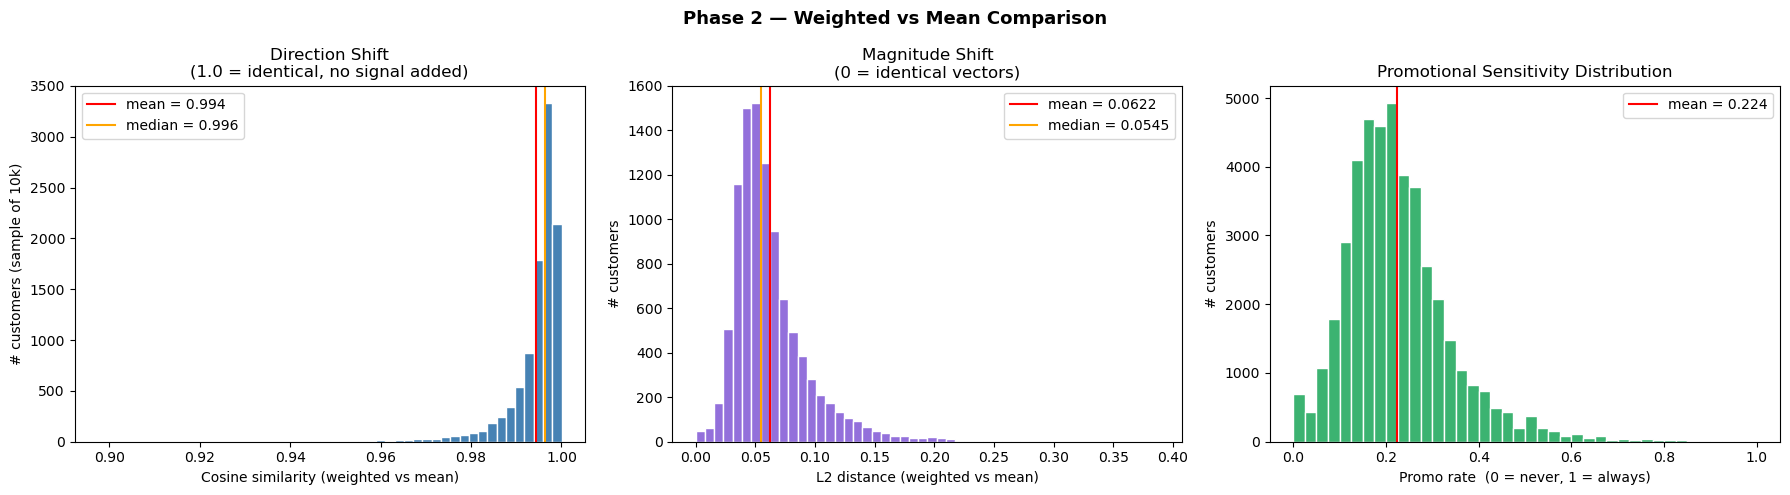

Cosine similarity:
  mean   : 0.9943
  median : 0.9963
  p25/p75: 0.9934 / 0.9978
  → Values < 1.0 confirm weighting shifted vectors — recency signal is real.

L2 distance:
  mean   : 0.062235
  median : 0.054536

Promo sensitivity:
  Pure loyalists (0% promo)  : 1.5% of customers
  Promo surfers (>50% promo) : 2.5% of customers


In [12]:
# Sample 10k customers present in both outputs
_common = cv_weighted.join(
    cv_mean.select(["cliente", "vector"]).rename({"vector": "vector_mean"}),
    on="cliente", how="inner",
).sample(n=min(10_000, len(cv_weighted)), seed=42)

_v_w = np.array(_common["vector"].to_list(),      dtype=np.float32)
_v_m = np.array(_common["vector_mean"].to_list(), dtype=np.float32)

# Row-wise cosine similarity
_cos_sim = (
    (_v_w * _v_m).sum(axis=1)
    / (np.linalg.norm(_v_w, axis=1) * np.linalg.norm(_v_m, axis=1) + 1e-9)
)

# Row-wise L2 distance
_l2_dist = np.linalg.norm(_v_w - _v_m, axis=1)

_promo = cv_weighted["promo_rate"].drop_nulls().to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(_cos_sim, bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(_cos_sim.mean(),     color="red",    lw=1.5, label=f"mean = {_cos_sim.mean():.3f}")
axes[0].axvline(np.median(_cos_sim), color="orange", lw=1.5, label=f"median = {np.median(_cos_sim):.3f}")
axes[0].set_xlabel("Cosine similarity (weighted vs mean)")
axes[0].set_ylabel("# customers (sample of 10k)")
axes[0].set_title("Direction Shift\n(1.0 = identical, no signal added)")
axes[0].legend()

axes[1].hist(_l2_dist, bins=50, color="mediumpurple", edgecolor="white")
axes[1].axvline(_l2_dist.mean(),     color="red",    lw=1.5, label=f"mean = {_l2_dist.mean():.4f}")
axes[1].axvline(np.median(_l2_dist), color="orange", lw=1.5, label=f"median = {np.median(_l2_dist):.4f}")
axes[1].set_xlabel("L2 distance (weighted vs mean)")
axes[1].set_ylabel("# customers")
axes[1].set_title("Magnitude Shift\n(0 = identical vectors)")
axes[1].legend()

axes[2].hist(_promo, bins=40, color="mediumseagreen", edgecolor="white")
axes[2].axvline(_promo.mean(), color="red", lw=1.5, label=f"mean = {_promo.mean():.3f}")
axes[2].set_xlabel("Promo rate  (0 = never, 1 = always)")
axes[2].set_ylabel("# customers")
axes[2].set_title("Promotional Sensitivity Distribution")
axes[2].legend()

plt.suptitle("Phase 2 — Weighted vs Mean Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS / "phase2_vector_comparison.png", dpi=120)
plt.show()

never_promo = (_promo == 0).mean() * 100
high_promo  = (_promo > 0.5).mean() * 100

print(f"Cosine similarity:")
print(f"  mean   : {_cos_sim.mean():.4f}")
print(f"  median : {np.median(_cos_sim):.4f}")
print(f"  p25/p75: {np.percentile(_cos_sim,25):.4f} / {np.percentile(_cos_sim,75):.4f}")
print(f"  → Values < 1.0 confirm weighting shifted vectors — recency signal is real.")
print(f"\nL2 distance:")
print(f"  mean   : {_l2_dist.mean():.6f}")
print(f"  median : {np.median(_l2_dist):.6f}")
print(f"\nPromo sensitivity:")
print(f"  Pure loyalists (0% promo)  : {never_promo:.1f}% of customers")
print(f"  Promo surfers (>50% promo) : {high_promo:.1f}% of customers")

### 3.2.5 Customer Vector Summary

Four customer vector representations are now available:

| Source | Description | Dims | Key property |
|---|---|---|---|
| `item2vec` | Recency+frequency-weighted mean of Item2Vec embeddings | 100 | Captures product-space semantics |
| `mean` | Unweighted mean of Item2Vec embeddings (baseline) | 100 | No recency signal |
| `tfidf_svd` | TF-IDF row-normalised customer×product matrix reduced by TruncatedSVD | 100 | Captures specific product affinity directly |
| `hybrid` | Concatenation of item2vec + tfidf_svd + product sector/type/theme shares | 200+ | Product-only candidate/fallback |
| `hybrid_with_store` | Same as `hybrid`, plus store spend shares | 200+ | Explicit store ablation, not the baseline |

**Selection flow:** The `VECTOR_SOURCE` run control (cell above) feeds one of these into UMAP. Section 3.2.6 runs a quick UMAP+HDBSCAN benchmark for each source under identical hyperparameters and scores them on organic cluster count, noise rate, and silhouette. The source that produces the most coherent 10–20 organic tribes is then used for the final pipeline in Section 3.3 onward. The default is `hybrid` — it is expected to outperform `item2vec` alone because the TF-IDF SVD block preserves specific product-affinity structure that is blurred by embedding averaging.

### 3.2.6 Vector Source Comparison: Method Selection Gate

This section is a method selection experiment. Candidate vector sources come from `configs/base.yaml -> model_selection.vector_sources`.

When `pipeline.vector_source: auto`, the winner selected here becomes the representation used by Section 3.3 onward and is persisted to `outputs/.../model_selection/vector_source_selection.json`.

No candidate is assumed to win in advance. `hybrid` is only the fallback before benchmark results exist.

In [13]:
# 3.2.6 Vector Source Comparison Benchmark
from src.config import VECTOR_BENCHMARK_N_SAMPLE, RANDOM_SEED

RUN_VECTOR_SOURCE_BENCHMARK   = globals().get('RUN_VECTOR_SOURCE_BENCHMARK',   True)
FORCE_VECTOR_SOURCE_BENCHMARK = globals().get('FORCE_VECTOR_SOURCE_BENCHMARK', False)
VECTOR_SOURCE_BENCHMARKS      = globals().get('VECTOR_SOURCE_BENCHMARKS',      list(VECTOR_SOURCE_CANDIDATES))
_target_clusters              = globals().get('TARGET_TRIBE_COUNT',            MODEL_SELECTION_TARGET_TRIBE_COUNT)
_vector_selection_path        = OUTPUTS / 'model_selection' / 'vector_source_selection.json'
out_path                      = DATA_PROCESSED / 'vector_source_hdbscan_comparison.parquet'

_bmark_n = VECTOR_BENCHMARK_N_SAMPLE
_full_n  = len(cv_candidates['item2vec'])
_scale   = _bmark_n / max(_full_n, 1)
_bmark_mcs = sorted(set(max(5, int(mcs * _scale)) for mcs in HDBSCAN_GRID_MIN_CLUSTER_SIZE))
_bmark_grid = {
    'min_cluster_sizes': _bmark_mcs,
    'min_samples_values': [1, 5],
    'cluster_methods':   ['leaf'],
}
print(f'Benchmark: {_bmark_n:,} customers / source | grid: {_bmark_mcs} x [1,5] x [leaf]')


def _select_best_hdbscan_candidate(grid_df, target_clusters=15):
    usable = grid_df.filter(pl.col('n_clusters') >= 2)
    if len(usable) == 0:
        usable = grid_df
    return (
        usable
        .with_columns((pl.col('n_clusters') - target_clusters).abs().alias('target_gap'))
        .sort(['target_gap', 'noise_pct', 'davies_bouldin'], nulls_last=True)
        .row(0, named=True)
    )


def _metric_or_empty(embedding_df, labels_df, method_name):
    try:
        return evaluate_clustering(embedding_df, labels_df, method_name)
    except ValueError:
        return {
            'method':         method_name,
            'n_clusters':     labels_df.filter(pl.col('cluster') >= 0)['cluster'].n_unique(),
            'noise_pct':      round(float((labels_df['cluster'] == -1).mean() * 100), 2),
            'silhouette':     None,
            'davies_bouldin': None,
        }


vector_source_results = []
vector_source_artifacts = {}

if RUN_VECTOR_SOURCE_BENCHMARK:
    for source in VECTOR_SOURCE_BENCHMARKS:
        if source not in cv_candidates:
            raise ValueError(f'Unknown vector source {source!r}; valid: {sorted(cv_candidates)}')

        print(f'\n=== Vector source: {source} ===')
        _t0 = time.time()
        _full_vectors = cv_candidates[source]
        _vectors = (
            _full_vectors.sample(n=min(_bmark_n, len(_full_vectors)), seed=RANDOM_SEED)
            if len(_full_vectors) > _bmark_n else _full_vectors
        )
        print(f'  Sample: {len(_vectors):,} / {len(_full_vectors):,} customers')

        bmark_umap_df = reduce_umap_cluster(
            _vectors,
            force=FORCE_VECTOR_SOURCE_BENCHMARK,
            cache_path=DATA_PROCESSED / f'umap_cluster_{source}_bmark.parquet',
        )
        grid_df = grid_search_hdbscan(
            bmark_umap_df,
            target_clusters=_target_clusters,
            force=FORCE_VECTOR_SOURCE_BENCHMARK,
            cache_path=DATA_PROCESSED / f'hdbscan_grid_{source}_bmark.parquet',
            **_bmark_grid,
        )
        best = _select_best_hdbscan_candidate(grid_df, target_clusters=_target_clusters)

        core_labels = cluster_hdbscan(
            bmark_umap_df,
            min_cluster_size=int(best['min_cluster_size']),
            min_samples=int(best['min_samples']),
            cluster_method=str(best['cluster_method']),
            force=FORCE_VECTOR_SOURCE_BENCHMARK,
            cache_path=DATA_PROCESSED / f'cluster_labels_hdbscan_{source}_bmark.parquet',
        )
        assigned_labels = assign_hdbscan_noise_to_nearest_tribe(
            bmark_umap_df,
            core_labels,
            force=FORCE_VECTOR_SOURCE_BENCHMARK,
            cache_path=DATA_PROCESSED / f'cluster_labels_hdbscan_assigned_{source}_bmark.parquet',
        )

        core_metrics = _metric_or_empty(bmark_umap_df, core_labels, f'{source}_hdbscan_core')
        assigned_metrics = _metric_or_empty(bmark_umap_df, assigned_labels, f'{source}_hdbscan_assigned')
        runtime_min = (time.time() - _t0) / 60

        vector_source_results.append({
            'vector_source':           source,
            'vector_dims':             len(_full_vectors['vector'][0]),
            'benchmark_sample':        len(_vectors),
            'best_min_cluster_size':   int(best['min_cluster_size']),
            'best_min_samples':        int(best['min_samples']),
            'best_cluster_method':     str(best['cluster_method']),
            'grid_n_clusters':         int(best['n_clusters']),
            'grid_noise_pct':          float(best['noise_pct']),
            'grid_silhouette':         best['silhouette'],
            'grid_davies_bouldin':     best['davies_bouldin'],
            'core_n_clusters':         core_metrics['n_clusters'],
            'core_noise_pct':          core_metrics['noise_pct'],
            'core_silhouette':         core_metrics['silhouette'],
            'core_davies_bouldin':     core_metrics['davies_bouldin'],
            'assigned_n_clusters':     assigned_metrics['n_clusters'],
            'assigned_from_noise_pct': round(float(assigned_labels['was_hdbscan_noise'].mean() * 100), 2),
            'assigned_silhouette':     assigned_metrics['silhouette'],
            'assigned_davies_bouldin': assigned_metrics['davies_bouldin'],
            'runtime_min':             round(runtime_min, 1),
        })
        vector_source_artifacts[source] = {
            'umap': bmark_umap_df,
            'grid': grid_df,
            'core_labels': core_labels,
            'assigned_labels': assigned_labels,
        }
        print(f'  Done in {runtime_min:.1f} min | organic clusters={assigned_metrics["n_clusters"]} | noise={core_metrics["noise_pct"]:.1f}%')

    vector_source_comparison = pd.DataFrame(vector_source_results)
    vector_source_comparison['target_gap'] = (vector_source_comparison['assigned_n_clusters'] - _target_clusters).abs()
    vector_source_comparison = vector_source_comparison.sort_values(
        ['target_gap', 'assigned_from_noise_pct', 'assigned_davies_bouldin'],
        ascending=[True, True, True],
    )
    display(vector_source_comparison)
    pl.from_pandas(vector_source_comparison).write_parquet(out_path, compression='zstd')

    _winner = select_vector_source(vector_source_comparison, target_clusters=_target_clusters)
    SELECTED_VECTOR_SOURCE = _winner['selected'] if is_auto(REQUESTED_VECTOR_SOURCE) else validate_choice(REQUESTED_VECTOR_SOURCE, cv_candidates.keys(), 'vector_source')
    write_selection_artifact(
        _vector_selection_path,
        component='vector_source',
        requested=REQUESTED_VECTOR_SOURCE,
        selected=SELECTED_VECTOR_SOURCE,
        fallback=PIPELINE_FALLBACK_VECTOR_SOURCE,
        candidates=VECTOR_SOURCE_BENCHMARKS,
        winner=_winner,
        comparison_path=out_path,
    )
    print(f'\nSelected vector source -> {SELECTED_VECTOR_SOURCE}')
    print(f'Selection artifact -> {_vector_selection_path}')
else:
    print('Vector source benchmark skipped.')
    _artifact = load_selection_artifact(_vector_selection_path)
    if is_auto(REQUESTED_VECTOR_SOURCE) and _artifact is not None:
        SELECTED_VECTOR_SOURCE = validate_choice(_artifact['selected'], cv_candidates.keys(), 'vector_source')
        print(f'Loaded persisted vector-source selection -> {SELECTED_VECTOR_SOURCE}')
    else:
        SELECTED_VECTOR_SOURCE = resolve_choice(
            REQUESTED_VECTOR_SOURCE,
            fallback=PIPELINE_FALLBACK_VECTOR_SOURCE,
            candidates=cv_candidates.keys(),
            component='vector_source',
        )
        print(f'Using configured/fallback vector source -> {SELECTED_VECTOR_SOURCE}')

VECTOR_SOURCE = SELECTED_VECTOR_SOURCE
cv_for_umap = cv_candidates[VECTOR_SOURCE]
print(f'\nDownstream vector source: {VECTOR_SOURCE} ({len(cv_for_umap["vector"][0])} dims)')

13:43:18 INFO UMAP cluster cache hit — 12,000 customers
13:43:18 INFO HDBSCAN grid cache hit — hdbscan_grid_item2vec_bmark.parquet
13:43:18 INFO HDBSCAN cache hit — 12,000 customers
13:43:18 INFO HDBSCAN assigned cache hit — cluster_labels_hdbscan_assigned_item2vec_bmark.parquet
13:43:18 INFO item2vec_hdbscan_core — 16 clusters | 58.6% noise | silhouette=0.3999 | DB=0.8714


Benchmark: 12,000 customers / source | grid: [6, 13, 27, 68, 136] x [1,5] x [leaf]

=== Vector source: item2vec ===
  Sample: 12,000 / 43,999 customers


13:43:18 INFO item2vec_hdbscan_assigned — 16 clusters | 0.0% noise | silhouette=0.1938 | DB=1.3279
13:43:18 INFO UMAP cluster cache hit — 12,000 customers
13:43:18 INFO HDBSCAN grid cache hit — hdbscan_grid_tfidf_svd_bmark.parquet
13:43:18 INFO HDBSCAN cache hit — 12,000 customers
13:43:18 INFO HDBSCAN assigned cache hit — cluster_labels_hdbscan_assigned_tfidf_svd_bmark.parquet
13:43:18 INFO tfidf_svd_hdbscan_core — 23 clusters | 51.6% noise | silhouette=0.5851 | DB=0.5845


  Done in 0.0 min | organic clusters=16 | noise=58.6%

=== Vector source: tfidf_svd ===
  Sample: 12,000 / 44,000 customers


13:43:18 INFO tfidf_svd_hdbscan_assigned — 23 clusters | 0.0% noise | silhouette=0.2957 | DB=0.9888
13:43:18 INFO UMAP cluster cache hit — 12,000 customers
13:43:18 INFO HDBSCAN grid cache hit — hdbscan_grid_hybrid_bmark.parquet
13:43:18 INFO HDBSCAN cache hit — 12,000 customers
13:43:18 INFO HDBSCAN assigned cache hit — cluster_labels_hdbscan_assigned_hybrid_bmark.parquet
13:43:18 INFO hybrid_hdbscan_core — 22 clusters | 57.2% noise | silhouette=0.5265 | DB=0.6864
13:43:19 INFO hybrid_hdbscan_assigned — 22 clusters | 0.0% noise | silhouette=0.2511 | DB=1.1762


  Done in 0.0 min | organic clusters=23 | noise=51.6%

=== Vector source: hybrid ===
  Sample: 12,000 / 43,999 customers
  Done in 0.0 min | organic clusters=22 | noise=57.2%


,vector_source,vector_dims,benchmark_sample,best_min_cluster_size,best_min_samples,best_cluster_method,grid_n_clusters,grid_noise_pct,grid_silhouette,grid_davies_bouldin,core_n_clusters,core_noise_pct,core_silhouette,core_davies_bouldin,assigned_n_clusters,assigned_from_noise_pct,assigned_silhouette,assigned_davies_bouldin,runtime_min,target_gap
0,item2vec,100,12000,136,1,leaf,16,58.58,0.3999,0.8714,16,58.58,0.3999,0.8714,16,58.58,0.1938,1.3279,0.0,1
2,hybrid,240,12000,136,5,leaf,22,57.16,0.5265,0.6864,22,57.16,0.5265,0.6864,22,57.16,0.2511,1.1762,0.0,7
1,tfidf_svd,100,12000,136,5,leaf,23,51.62,0.5851,0.5845,23,51.62,0.5851,0.5845,23,51.62,0.2957,0.9888,0.0,8



Selected vector source -> item2vec
Selection artifact -> C:\Users\sebog\proyectos\carrefour_capstone\outputs\dev\model_selection\vector_source_selection.json

Downstream vector source: item2vec (100 dims)


### 3.2.7 Store Affinity Features

Compute store-format spend shares for profiling and optional modeling context.

13:43:19 INFO Store features cache hit — 44,000 customers


Stores in data         : ['spend_share_s6', 'spend_share_s7', 'spend_share_s2', 'spend_share_s11']
Customers with store data: 44,000

Store reach (% of customers who spend anything at each store):
  spend_share_s6        :  23.9% shop there  |    5.7% spend >80% there
  spend_share_s7        :  78.0% shop there  |   62.6% spend >80% there
  spend_share_s2        :  39.6% shop there  |   17.9% spend >80% there
  spend_share_s11       :   2.5% shop there  |    0.1% spend >80% there

Cross-store shopping behaviour:
  Single-store loyalists (only 1 store) : 62.1%
  2-store shoppers                      : 31.8%
  3+ store shoppers                     : 6.0%


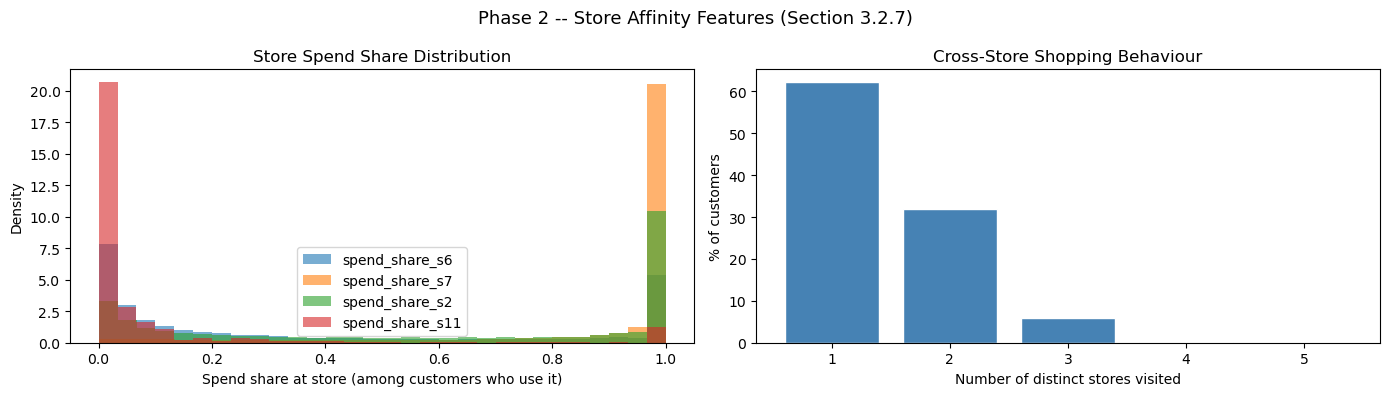


→ Store spend shares: profile-only in the product baseline. Use VECTOR_SOURCE='hybrid_with_store' or FEATURE_WEIGHT_STORE > 0 for an explicit store ablation.
→ With the default product-only baseline, tribes are driven by product embeddings, product affinity, and product-share features.


In [14]:
# 3.2.7 Store affinity features
from src.customer_vectors import build_store_features

store_feats = build_store_features()   # cached after first run

store_cols = [c for c in store_feats.columns if c != "cliente"]
store_arr  = store_feats.select(store_cols).to_numpy()
n_stores_active = (store_arr > 0).sum(axis=1)   # how many stores each customer uses

print(f"Stores in data         : {store_cols}")
print(f"Customers with store data: {len(store_feats):,}")
print()

print("Store reach (% of customers who spend anything at each store):")
for col in store_cols:
    pct_any      = (store_feats[col] > 0).mean() * 100
    pct_dominant = (store_feats[col] > 0.8).mean() * 100
    print(f"  {col:<22}: {pct_any:5.1f}% shop there  |  {pct_dominant:5.1f}% spend >80% there")

print()
print("Cross-store shopping behaviour:")
print(f"  Single-store loyalists (only 1 store) : {(n_stores_active == 1).mean()*100:.1f}%")
print(f"  2-store shoppers                      : {(n_stores_active == 2).mean()*100:.1f}%")
print(f"  3+ store shoppers                     : {(n_stores_active >= 3).mean()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Store spend share distributions
for col in store_cols:
    vals = store_feats.filter(pl.col(col) > 0)[col].to_numpy()
    axes[0].hist(vals, bins=30, alpha=0.6, label=col, density=True)
axes[0].set_xlabel("Spend share at store (among customers who use it)")
axes[0].set_ylabel("Density")
axes[0].set_title("Store Spend Share Distribution")
axes[0].legend()

# Cross-store shopping
axes[1].bar(range(1, len(store_cols)+2),
            [(n_stores_active == k).mean()*100 for k in range(1, len(store_cols)+2)],
            color="steelblue", edgecolor="white")
axes[1].set_xlabel("Number of distinct stores visited")
axes[1].set_ylabel("% of customers")
axes[1].set_title("Cross-Store Shopping Behaviour")

plt.suptitle("Phase 2 -- Store Affinity Features (Section 3.2.7)", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUTS / "phase2_store_affinity.png", dpi=120)
plt.show()

print()
print("→ Store spend shares: profile-only in the product baseline. Use VECTOR_SOURCE='hybrid_with_store' or FEATURE_WEIGHT_STORE > 0 for an explicit store ablation.")
print("→ With the default product-only baseline, tribes are driven by product embeddings, product affinity, and product-share features.")

<a id="33-dimensionality-reduction"></a>
## 3.3 Representation Comparison: UMAP vs PCA

Compare whether a linear projection or nonlinear manifold projection gives a more useful clustering space. This is a representation test, not a final business decision.

### 3.3.1 UMAP Clustering Embedding

Create the primary product-led UMAP embedding used by HDBSCAN and K-Means clustering.

**Why `n_neighbors=20` (lowered from the initial value of 50)**

`n_neighbors` is the single most impactful UMAP hyperparameter for cluster granularity. A high value (50) makes UMAP stitch together large neighbourhoods → the manifold has broad, sweeping regions → HDBSCAN finds only 4–6 organic density peaks. A low value (15–25) preserves local structure → small, cohesive product-behaviour groups stay separated → HDBSCAN can resolve 10–20 organic tribes.

The sensitivity analysis in **Section 3.3.1a** (immediately after the full UMAP run) validates this choice on a held-out sample: it shows organic cluster count as a function of n_neighbors and confirms that n_neighbors=20 falls in the target range of 10–20 tribes while larger values collapse that structure.

In [15]:
# 3.3.1 Dimensionality-reduction candidate: UMAP
REQUESTED_REDUCER = REDUCER
_reducer_candidates = list(REDUCER_BENCHMARKS)
if is_auto(REQUESTED_REDUCER):
    if PIPELINE_FALLBACK_REDUCER not in _reducer_candidates:
        _reducer_candidates.append(PIPELINE_FALLBACK_REDUCER)
else:
    if REQUESTED_REDUCER not in _reducer_candidates:
        _reducer_candidates.append(REQUESTED_REDUCER)

reduction_artifacts = {}
umap_cluster = None

if 'umap' in _reducer_candidates:
    _t0 = time.time()
    umap_cluster = reduce_umap_cluster(
        cv_for_umap,
        force=FORCE_UMAP,
        cache_path=DATA_PROCESSED / f'umap_cluster_{VECTOR_SOURCE}.parquet',
    )
    reduction_artifacts['umap'] = umap_cluster
    _elapsed = time.time() - _t0
    _dim_count = len([c for c in umap_cluster.columns if c not in ('cliente', 'promo_rate')])
    print(f'UMAP {_dim_count}D done in {_elapsed/60:.1f} min')
    print(f'Shape : {umap_cluster.shape[0]:,} customers x {_dim_count} dims')
    print(umap_cluster.head(3))
else:
    print('UMAP skipped because it is not in reducer candidates.')

13:43:19 INFO UMAP cluster cache hit — 43,999 customers


UMAP 50D done in 0.0 min
Shape : 43,999 customers x 50 dims
shape: (3, 52)
┌───────────────┬──────────┬──────────┬──────────┬───┬──────────┬──────────┬──────────┬────────────┐
│ cliente       ┆ u0       ┆ u1       ┆ u2       ┆ … ┆ u47      ┆ u48      ┆ u49      ┆ promo_rate │
│ ---           ┆ ---      ┆ ---      ┆ ---      ┆   ┆ ---      ┆ ---      ┆ ---      ┆ ---        │
│ str           ┆ f32      ┆ f32      ┆ f32      ┆   ┆ f32      ┆ f32      ┆ f32      ┆ f32        │
╞═══════════════╪══════════╪══════════╪══════════╪═══╪══════════╪══════════╪══════════╪════════════╡
│ 0000d81642228 ┆ 7.653289 ┆ 4.621661 ┆ 4.168298 ┆ … ┆ 4.120557 ┆ 6.085103 ┆ 6.028012 ┆ 0.323529   │
│ 5eab6ae3781cc ┆          ┆          ┆          ┆   ┆          ┆          ┆          ┆            │
│ e277…         ┆          ┆          ┆          ┆   ┆          ┆          ┆          ┆            │
│ 0002bcdc4b99e ┆ 9.967496 ┆ 7.272965 ┆ 3.599069 ┆ … ┆ 4.086574 ┆ 6.082583 ┆ 6.028496 ┆ 0.2        │
│ c40582b2c1000 

### 3.3.1a n_neighbors Sensitivity Analysis

Validate the `n_neighbors=20` choice by running UMAP+HDBSCAN on a held-out sample across five candidate values: 10, 15, 20, 30, 50. This is a lightweight experiment (runs on 8 k customers, takes ~30 s) that directly shows how the neighbourhood size controls the number of organic density clusters that HDBSCAN can discover.

**Reading the table:** Higher n_neighbors → UMAP emphasises global structure → fewer, broader clusters. Lower n_neighbors → UMAP preserves local structure → more, finer clusters but potentially noisier. We want 10–20 tribes, so the n_neighbors value closest to that range with acceptable noise is preferred.

In [16]:
# 3.3.1a — n_neighbors sensitivity analysis on a held-out sample
# Dev only: validates the configured n_neighbors choice.
# Prod: skipped (n_neighbors already validated in dev; value is in configs/base.yaml).
RUN_N_NEIGHBORS_SENSITIVITY = globals().get('RUN_N_NEIGHBORS_SENSITIVITY', MODE == 'dev')
if not RUN_N_NEIGHBORS_SENSITIVITY:
    print(f'n_neighbors sensitivity skipped (prod mode). Configured: n_neighbors={UMAP_N_NEIGHBORS}')
else:
    import time
    import umap as _umap_lib
    from sklearn.cluster import HDBSCAN as _HDBSCAN_sk
    from src.config import (
        HDBSCAN_MIN_CLUSTER_SIZE,
        HDBSCAN_MIN_SAMPLES,
        HDBSCAN_CLUSTER_METHOD,
        RANDOM_SEED,
        UMAP_CLUSTER_DIMS,
        UMAP_N_NEIGHBORS,
    )

    _SENS_SAMPLE = min(8_000, len(cv_for_umap))
    _rng = np.random.default_rng(RANDOM_SEED)
    _sidx = _rng.choice(len(cv_for_umap), _SENS_SAMPLE, replace=False)
    _X_sens = np.array(cv_for_umap["vector"].to_list(), dtype=np.float32)[_sidx]

    _nn_candidates = list(N_NEIGHBORS_CANDIDATES)
    _sens_rows = []

    # Scale min_cluster_size down proportionally for the sample
    _mcs_sample = max(5, HDBSCAN_MIN_CLUSTER_SIZE * _SENS_SAMPLE // max(len(cv_for_umap), 1))

    print(f"n_neighbors sensitivity on {_SENS_SAMPLE:,} customers  "
          f"(min_cluster_size={_mcs_sample}, method={HDBSCAN_CLUSTER_METHOD})")
    print("-" * 70)

    for _nn in _nn_candidates:
        _t = time.time()
        _reducer = _umap_lib.UMAP(
            n_components=min(UMAP_CLUSTER_DIMS, 20),   # 20D is enough for this quick check
            n_neighbors=_nn,
            min_dist=0.05,
            metric="cosine",
            random_state=RANDOM_SEED,
            n_jobs=1,
            low_memory=True,
        )
        _emb = _reducer.fit_transform(_X_sens)
        _cl = _HDBSCAN_sk(
            min_cluster_size=_mcs_sample,
            min_samples=HDBSCAN_MIN_SAMPLES,
            metric="euclidean",
            cluster_selection_method=HDBSCAN_CLUSTER_METHOD,
            n_jobs=1,
        ).fit_predict(_emb)
        _n_organic = int(len(set(_cl)) - (1 if -1 in _cl else 0))
        _noise = float((_cl == -1).mean() * 100)
        _secs = time.time() - _t
        _selected = " ← CONFIGURED" if _nn == UMAP_N_NEIGHBORS else ""
        _sens_rows.append({
            "n_neighbors": _nn,
            "organic_clusters": _n_organic,
            "noise_pct": round(_noise, 1),
            "runtime_s": round(_secs, 1),
            "note": _selected.strip(),
        })
        print(f"  n_neighbors={_nn:2d}  →  {_n_organic:2d} organic clusters  "
              f"| noise={_noise:.1f}%  | {_secs:.1f}s{_selected}")

    _sens_pd = pd.DataFrame(_sens_rows)
    print()
    print("Summary table:")
    print(_sens_pd.to_string(index=False))
    print()
    print(f"Configured n_neighbors = {UMAP_N_NEIGHBORS}  (see configs/base.yaml  umap.n_neighbors)")
    print("Target: 10–20 organic tribes.  Confirm the configured value sits in or near that range.")

n_neighbors sensitivity skipped (prod mode). Configured: n_neighbors=20


### 3.3.2 PCA Baseline

Fit a linear PCA baseline. If PCA clusters are just as readable as UMAP clusters, prefer the simpler representation.

13:43:19 INFO PCA cache hit — 43,999 customers


PCA done in 0 s
Explained variance - 10 PCs: 70.1% | 20 PCs: 81.7%


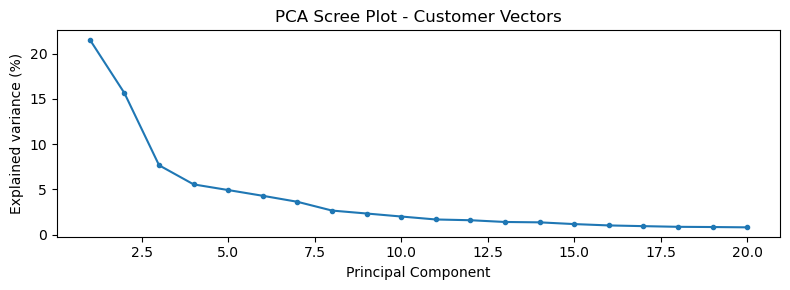

In [17]:
# 3.3.2 Dimensionality-reduction candidate: PCA
pca_cluster = None
pca_model = None

if 'pca' in _reducer_candidates:
    _t0 = time.time()
    pca_cluster, pca_model = reduce_pca(
        cv_for_umap,
        force=FORCE_UMAP,
        cache_path=DATA_PROCESSED / f'pca_cluster_{VECTOR_SOURCE}.parquet',
        model_path=DATA_PROCESSED / f'pca_model_{VECTOR_SOURCE}.pkl',
    )
    reduction_artifacts['pca'] = pca_cluster
    _elapsed = time.time() - _t0
    explained = pca_model.explained_variance_ratio_.cumsum()
    print(f"PCA done in {_elapsed:.0f} s")
    print(f"Explained variance - 10 PCs: {explained[9]:.1%} | 20 PCs: {explained[19]:.1%}")

    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(range(1, 21), pca_model.explained_variance_ratio_[:20] * 100, marker="o", ms=3)
    ax.set_xlabel("Principal Component")
    ax.set_ylabel("Explained variance (%)")
    ax.set_title("PCA Scree Plot - Customer Vectors")
    plt.tight_layout()
    plt.savefig(OUTPUTS / "phase3_pca_scree.png", dpi=120)
    plt.show()
else:
    print('PCA skipped because it is not in reducer candidates.')

### 3.3.3 UMAP 2D Visualization Embedding

Project the clustering space to two dimensions for visual inspection and cluster maps.

13:43:19 INFO UMAP viz cache hit — 43,999 customers


UMAP 2D preview done in 0.0 min


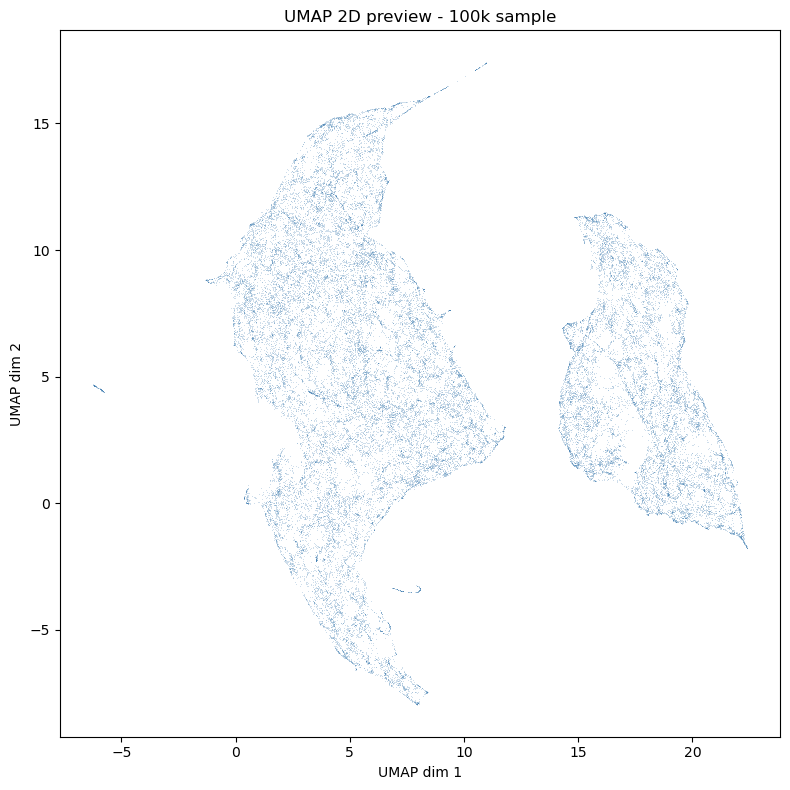

In [18]:
# 3.3.3 UMAP 2D visualization preview
# The final 2D plot is rebuilt from the selected reducer in Section 3.3.5.
_t0 = time.time()

if umap_cluster is not None:
    umap_viz = reduce_umap_viz(
        umap_cluster,
        force=FORCE_UMAP,
        cache_path=DATA_PROCESSED / f'umap_viz_{VECTOR_SOURCE}_umap_preview_2d.parquet',
    )
    _elapsed = time.time() - _t0
    print(f"UMAP 2D preview done in {_elapsed/60:.1f} min")

    _sample = umap_viz.sample(n=min(100_000, len(umap_viz)), seed=42)
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(_sample["x"].to_numpy(), _sample["y"].to_numpy(),
               s=0.3, alpha=0.3, c="steelblue", linewidths=0)
    ax.set_title("UMAP 2D preview - 100k sample")
    ax.set_xlabel("UMAP dim 1"); ax.set_ylabel("UMAP dim 2")
    plt.tight_layout()
    plt.savefig(OUTPUTS / "phase3_umap2d_preview.png", dpi=120)
    plt.show()
else:
    umap_viz = None
    print('UMAP 2D preview skipped because UMAP was not built.')

### 3.3.4 UMAP Structure Preservation Check

Check whether the UMAP embeddings preserve nearest-neighbour structure from the original customer-vector space.

UMAP preservation check: 5,000 customers, k=30, original_metric=cosine
Original feature-space dims: 100 | UMAP dims: 50 -> 2
embedding trustworthiness knn_overlap
 UMAP 50D           0.912       0.217
  UMAP 2D           0.861       0.140


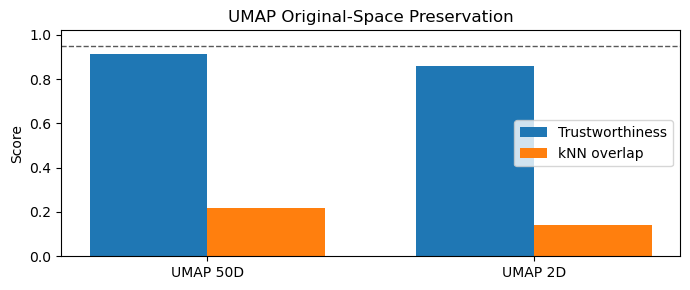

In [19]:
from sklearn.manifold import trustworthiness
from sklearn.neighbors import NearestNeighbors
from src.config import UMAP_METRIC

UMAP_EVAL_SAMPLE = min(5_000, len(cv_for_umap))
UMAP_EVAL_K = 30

_umap_cols = [c for c in umap_cluster.columns if c.startswith("u")]
_eval = (
    cv_for_umap.select(["cliente", "vector", "promo_rate"])
    .sample(n=UMAP_EVAL_SAMPLE, seed=42)
    .join(umap_cluster.select(["cliente"] + _umap_cols), on="cliente", how="inner")
    .join(umap_viz.select(["cliente", "x", "y"]), on="cliente", how="inner")
)

_X_parts = [np.array(_eval["vector"].to_list(), dtype=np.float32)]

if FEATURE_WEIGHT_PROMO > 0:
    _promo = _eval["promo_rate"].fill_null(0.0).to_numpy().reshape(-1, 1).astype(np.float32)
    _X_parts.append(_promo * FEATURE_WEIGHT_PROMO)

if FEATURE_WEIGHT_STORE > 0:
    _store_df = store_feats if "store_feats" in globals() else pl.read_parquet(DATA_PROCESSED / "customer_store_features.parquet")
    _store_cols = [c for c in _store_df.columns if c != "cliente"]
    _store_eval = (
        _eval.select("cliente")
        .join(_store_df, on="cliente", how="left")
        .fill_null(0.0)
        .select(_store_cols)
        .to_numpy()
        .astype(np.float32)
    )
    _X_parts.append(_store_eval * FEATURE_WEIGHT_STORE)

if FEATURE_WEIGHT_KPI > 0:
    _kpi_path = DATA_PROCESSED / "customer_kpis.parquet"
    if _kpi_path.exists():
        _kpi_cols = ["total_spend_6m", "visit_count", "avg_basket_size", "unique_products"]
        _kpi_eval = (
            _eval.select("cliente")
            .join(pl.read_parquet(_kpi_path).select(["cliente"] + _kpi_cols), on="cliente", how="left")
            .fill_null(0.0)
            .select(_kpi_cols)
            .to_numpy()
            .astype(np.float64)
        )
        _kpi_eval = np.log1p(_kpi_eval)
        _kpi_eval = (_kpi_eval - _kpi_eval.mean(axis=0)) / (_kpi_eval.std(axis=0) + 1e-8)
        _X_parts.append((_kpi_eval * FEATURE_WEIGHT_KPI).astype(np.float32))
    else:
        print("KPI features enabled, but customer_kpis.parquet was not found for this check.")

_X_original = np.hstack(_X_parts).astype(np.float32)
_X_umap = _eval.select(_umap_cols).to_numpy().astype(np.float32)
_X_viz = _eval.select(["x", "y"]).to_numpy().astype(np.float32)
_k = min(UMAP_EVAL_K, len(_eval) - 1)

def _neighbor_sets(X, k, metric):
    nn = NearestNeighbors(n_neighbors=k + 1, metric=metric, n_jobs=-1)
    idx = nn.fit(X).kneighbors(return_distance=False)
    return idx[:, 1:]

def _mean_neighbor_overlap(reference_idx, reduced_idx):
    return float(np.mean([
        len(set(a).intersection(b)) / len(a)
        for a, b in zip(reference_idx, reduced_idx)
    ]))

_orig_nn = _neighbor_sets(_X_original, _k, UMAP_METRIC)
_umap_nn = _neighbor_sets(_X_umap, _k, "euclidean")
_viz_nn = _neighbor_sets(_X_viz, _k, "euclidean")

_quality = pd.DataFrame({
    "embedding": [f"UMAP {_X_umap.shape[1]}D", "UMAP 2D"],
    "trustworthiness": [
        trustworthiness(_X_original, _X_umap, n_neighbors=_k, metric=UMAP_METRIC),
        trustworthiness(_X_original, _X_viz, n_neighbors=_k, metric=UMAP_METRIC),
    ],
    "knn_overlap": [
        _mean_neighbor_overlap(_orig_nn, _umap_nn),
        _mean_neighbor_overlap(_orig_nn, _viz_nn),
    ],
})

print(f"UMAP preservation check: {len(_eval):,} customers, k={_k}, original_metric={UMAP_METRIC}")
print(f"Original feature-space dims: {_X_original.shape[1]} | UMAP dims: {_X_umap.shape[1]} -> 2")
print(_quality.to_string(index=False, formatters={
    "trustworthiness": "{:.3f}".format,
    "knn_overlap": "{:.3f}".format,
}))

fig, ax = plt.subplots(figsize=(7, 3))
x = np.arange(len(_quality))
width = 0.36
ax.bar(x - width/2, _quality["trustworthiness"], width, label="Trustworthiness")
ax.bar(x + width/2, _quality["knn_overlap"], width, label="kNN overlap")
ax.axhline(0.95, color="0.35", lw=1, ls="--")
ax.set_xticks(x)
ax.set_xticklabels(_quality["embedding"])
ax.set_ylim(0, 1.02)
ax.set_ylabel("Score")
ax.set_title("UMAP Original-Space Preservation")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS / "phase3_umap_preservation.png", dpi=120)
plt.show()

### 3.3.5 UMAP vs PCA Comparison

Compare UMAP and PCA as inputs for customer segmentation.

In [20]:
from sklearn.cluster import MiniBatchKMeans

_REDUCER_SELECTION_PATH = OUTPUTS / 'model_selection' / 'reducer_selection.json'
_K = globals().get('TARGET_TRIBE_COUNT', MODEL_SELECTION_TARGET_TRIBE_COUNT)


def _quick_silhouette(df, k=_K, sample=REDUCTION_BENCHMARK_SAMPLE, seed=42):
    dim_cols = [c for c in df.columns if c not in ("cliente", "promo_rate")]
    X = df.select(dim_cols).to_numpy().astype("float32")
    km = MiniBatchKMeans(n_clusters=int(k), random_state=seed, n_init=3, batch_size=5000)
    lbl = km.fit_predict(X)
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), min(sample, len(X)), replace=False)
    return silhouette_score(X[idx], lbl[idx], metric="euclidean")


if not reduction_artifacts:
    raise RuntimeError('No reducer artifacts were built. Check REDUCER_BENCHMARKS / REDUCER config.')

print(f"Computing reducer benchmark scores (proxy K={_K}, sample={REDUCTION_BENCHMARK_SAMPLE:,}) ...")
reduction_rows = []
for _name, _df in reduction_artifacts.items():
    _dim_count = len([c for c in _df.columns if c not in ('cliente', 'promo_rate')])
    _sil = _quick_silhouette(_df)
    reduction_rows.append({
        'reducer': _name,
        'dims': _dim_count,
        'silhouette': round(float(_sil), 4),
        'davies_bouldin': None,
    })

reduction_comparison = pd.DataFrame(reduction_rows).sort_values('silhouette', ascending=False)
display(reduction_comparison)

if is_auto(REQUESTED_REDUCER):
    _winner = select_reducer(reduction_comparison)
    SELECTED_REDUCER = _winner['selected']
else:
    SELECTED_REDUCER = validate_choice(REQUESTED_REDUCER, reduction_artifacts.keys(), 'reducer')
    _winner = reduction_comparison.loc[reduction_comparison['reducer'].eq(SELECTED_REDUCER)].iloc[0].to_dict()

write_selection_artifact(
    _REDUCER_SELECTION_PATH,
    component='reducer',
    requested=REQUESTED_REDUCER,
    selected=SELECTED_REDUCER,
    fallback=PIPELINE_FALLBACK_REDUCER,
    candidates=list(reduction_artifacts.keys()),
    winner=_winner,
)

REDUCER = SELECTED_REDUCER
cluster_space = reduction_artifacts[SELECTED_REDUCER]
_cluster_dim_count = len([c for c in cluster_space.columns if c not in ('cliente', 'promo_rate')])
print(f"\nSelected reducer -> {SELECTED_REDUCER} ({_cluster_dim_count} dims)")
print(f"Selection artifact -> {_REDUCER_SELECTION_PATH}")

_t0 = time.time()
umap_viz = reduce_umap_viz(
    cluster_space,
    force=FORCE_UMAP,
    cache_path=DATA_PROCESSED / f'umap_viz_{VECTOR_SOURCE}_{SELECTED_REDUCER}_2d.parquet',
)
_elapsed = time.time() - _t0
print(f"Selected-space 2D visualization done in {_elapsed/60:.1f} min")

Computing reducer benchmark scores (proxy K=15, sample=50,000) ...


,reducer,dims,silhouette,davies_bouldin
0,umap,50,0.2786,None
1,pca,50,0.0497,None


13:44:05 INFO UMAP viz cache hit — 43,999 customers



Selected reducer -> umap (50 dims)
Selection artifact -> C:\Users\sebog\proyectos\carrefour_capstone\outputs\dev\model_selection\reducer_selection.json
Selected-space 2D visualization done in 0.0 min


### 3.3.6 Dimensionality Reduction Summary

Use this section as a geometry check. The final representation still has to win on product/theme profile readability.

<a id="34-clustering-experiments"></a>
## 3.4 Clustering, Profiling and Tribe Selection

Compare density-based discovery with fixed-K business baselines, then profile every candidate. The final choice should be the segmentation that produces useful product tribes, not the highest geometry score.

### 3.4.1 HDBSCAN Grid Search and Configured HDBSCAN

Search HDBSCAN hyperparameters and generate the configured density-based labels for the full customer population.

**Dev → Prod scaling note:** `min_cluster_size` is an absolute customer count, not a percentage. The value tuned on dev (≈44 k customers) will not auto-translate to prod (≈1.08 M eligible customers). After reviewing the grid, use the scaling cell below to read the winning row and print the recommended prod values:

```
prod_min_cluster_size = dev_min_cluster_size × (prod_n / dev_n)
```

Paste the output into `configs/base.yaml` → `hdbscan.min_cluster_size` and `hdbscan.min_samples`, then re-run in prod mode.

In [21]:
# -- 3.4.1 HDBSCAN: optional full grid + configured/selected run -----------
RUN_HDBSCAN_GRID_SEARCH = globals().get('RUN_HDBSCAN_GRID_SEARCH', False)

_hdbscan_run_params = {
    'min_cluster_size': int(HDBSCAN_MIN_CLUSTER_SIZE),
    'min_samples': int(HDBSCAN_MIN_SAMPLES),
    'cluster_method': str(HDBSCAN_CLUSTER_METHOD),
}
hdb_grid = None

if RUN_HDBSCAN_GRID_SEARCH:
    _t0 = time.time()
    hdb_grid = grid_search_hdbscan(
        cluster_space,
        target_clusters=TARGET_TRIBE_COUNT,
        force=FORCE_CLUSTERING,
        cache_path=DATA_PROCESSED / f'hdbscan_grid_{VECTOR_SOURCE}_{SELECTED_REDUCER}_full.parquet',
    )
    _elapsed = time.time() - _t0
    print(f'HDBSCAN grid search done in {_elapsed/60:.1f} min')
    hdb_grid_view = hdb_grid.with_columns([
        (100 - pl.col('noise_pct')).round(2).alias('coverage_pct'),
        (pl.col('silhouette') * (1 - pl.col('noise_pct') / 100)).round(4).alias('coverage_adj_silhouette'),
    ])
    print('Top HDBSCAN candidates, sorted by closeness to target K and noise:')
    print(hdb_grid_view.head(12).to_pandas().to_string(index=False))

    best_row = hdb_grid.head(1).to_dicts()[0]
    _hdbscan_run_params = {
        'min_cluster_size': int(best_row['min_cluster_size']),
        'min_samples': int(best_row['min_samples']),
        'cluster_method': str(best_row['cluster_method']),
    }
    print('\nUsing best full-grid row for this run:', _hdbscan_run_params)
else:
    print('Full HDBSCAN grid search skipped.')
    if 'vector_source_comparison' in globals() and isinstance(vector_source_comparison, pd.DataFrame):
        _match = vector_source_comparison.loc[vector_source_comparison['vector_source'].eq(VECTOR_SOURCE)]
        if len(_match) > 0:
            _row = _match.iloc[0]
            _hdbscan_run_params = {
                'min_cluster_size': int(_row['best_min_cluster_size']),
                'min_samples': int(_row['best_min_samples']),
                'cluster_method': str(_row['best_cluster_method']),
            }
            print('Using 3.2.6 sampled benchmark params for selected source:', _hdbscan_run_params)
        else:
            print('No 3.2.6 benchmark row for selected source; using config params:', _hdbscan_run_params)
    else:
        print('No 3.2.6 benchmark table in memory; using config params:', _hdbscan_run_params)

_hdb_suffix = (
    f"{VECTOR_SOURCE}_{SELECTED_REDUCER}_mcs{_hdbscan_run_params['min_cluster_size']}"
    f"_ms{_hdbscan_run_params['min_samples']}_{_hdbscan_run_params['cluster_method']}"
)
_t0 = time.time()
hdb_core_labels = cluster_hdbscan(
    cluster_space,
    force=FORCE_CLUSTERING,
    cache_path=DATA_PROCESSED / f'cluster_labels_hdbscan_{_hdb_suffix}.parquet',
    **_hdbscan_run_params,
)
hdb_labels = hdb_core_labels

_elapsed = time.time() - _t0
n_tribes  = hdb_core_labels['cluster'].filter(hdb_core_labels['cluster'] >= 0).n_unique()
noise_n   = int((hdb_core_labels['cluster'] == -1).sum())
noise_pct = noise_n / len(hdb_core_labels) * 100

print(f'\nHDBSCAN run done in {_elapsed/60:.1f} min')
print(f'Params       : {_hdbscan_run_params}')
print(f'Tribes found : {n_tribes}')
print(f'Noise        : {noise_n:,}  ({noise_pct:.1f}% of customers)')
print(f'\nCustomers per tribe (top 10):')
print(hdb_core_labels['cluster'].value_counts()
      .filter(pl.col('cluster') >= 0)
      .sort('count', descending=True)
      .head(10))

hdb_assigned_labels = assign_hdbscan_noise_to_nearest_tribe(
    cluster_space,
    hdb_core_labels,
    force=FORCE_CLUSTERING,
    cache_path=DATA_PROCESSED / f'cluster_labels_hdbscan_assigned_{_hdb_suffix}.parquet',
)

print('\nHDBSCAN-derived all-customer assignment:')
print(f'Assigned tribes : {hdb_assigned_labels["cluster"].n_unique()}')
print(f'Nearest-assigned from HDBSCAN noise: '
      f'{hdb_assigned_labels["was_hdbscan_noise"].mean() * 100:.1f}%')
print(hdb_assigned_labels['cluster'].value_counts().sort('count', descending=True).head(10))

13:44:05 INFO HDBSCAN cache hit — 43,999 customers
13:44:05 INFO HDBSCAN assigned cache hit — cluster_labels_hdbscan_assigned_item2vec_umap_mcs136_ms1_leaf.parquet


Full HDBSCAN grid search skipped.
Using 3.2.6 sampled benchmark params for selected source: {'min_cluster_size': 136, 'min_samples': 1, 'cluster_method': 'leaf'}

HDBSCAN run done in 0.0 min
Params       : {'min_cluster_size': 136, 'min_samples': 1, 'cluster_method': 'leaf'}
Tribes found : 12
Noise        : 23,281  (52.9% of customers)

Customers per tribe (top 10):
shape: (10, 2)
┌─────────┬───────┐
│ cluster ┆ count │
│ ---     ┆ ---   │
│ i32     ┆ u32   │
╞═════════╪═══════╡
│ 2       ┆ 4618  │
│ 1       ┆ 3517  │
│ 4       ┆ 2555  │
│ 5       ┆ 1589  │
│ 10      ┆ 1473  │
│ 8       ┆ 1457  │
│ 9       ┆ 1402  │
│ 6       ┆ 1378  │
│ 7       ┆ 1070  │
│ 11      ┆ 645   │
└─────────┴───────┘

HDBSCAN-derived all-customer assignment:
Assigned tribes : 12
Nearest-assigned from HDBSCAN noise: 52.9%
shape: (10, 2)
┌─────────┬───────┐
│ cluster ┆ count │
│ ---     ┆ ---   │
│ i32     ┆ u32   │
╞═════════╪═══════╡
│ 2       ┆ 9776  │
│ 1       ┆ 4830  │
│ 4       ┆ 3747  │
│ 9       ┆ 374

In [22]:
# -- Dev → Prod hyperparameter translation ---------------------------------
# min_cluster_size is an ABSOLUTE customer count.
# A value tuned on dev does not transfer to prod without scaling.
#
# Formula: prod_mcs = dev_mcs × (prod_n / dev_n)
#
# _PROD_N_CUSTOMERS: eligible customers after min_tickets_per_customer filter.
# Source: data/processed/quality_report.json — update if data changes.
if RUN_HDBSCAN_GRID_SEARCH and hdb_grid is not None:
    dev_n = len(cluster_space)
    _PROD_N_CUSTOMERS = 1_082_000  # from quality report; update if data changes
    _scale = _PROD_N_CUSTOMERS / dev_n

    best_row = hdb_grid.head(1).to_dicts()[0]
    dev_mcs  = int(best_row['min_cluster_size'])
    dev_ms   = int(best_row['min_samples'])
    dev_cm   = best_row['cluster_method']
    prod_mcs = max(1, round(dev_mcs * _scale))

    print('=' * 62)
    print('Dev -> Prod HDBSCAN hyperparameter translation')
    print('=' * 62)
    print(f'Dev  population  : {dev_n:>10,}')
    print(f'Prod population  : {_PROD_N_CUSTOMERS:>10,}  (update if data changes)')
    print(f'Scale factor     : {_scale:>10.1f}x')
    print()
    print(f'Best dev grid row:')
    print(f'  min_cluster_size  = {dev_mcs}')
    print(f'  min_samples       = {dev_ms}')
    print(f'  cluster_method    = {dev_cm}')
    print()
    print(f'Suggested prod values (paste into configs/base.yaml):')
    print(f'  hdbscan:')
    print(f'    min_cluster_size: {prod_mcs}  # {prod_mcs / _PROD_N_CUSTOMERS * 100:.2f}% of prod population')
    print(f'    min_samples: {dev_ms}  # keep same absolute value as dev')
    print(f'    cluster_method: {dev_cm}')
    print()
    print('Note: min_samples is usually kept at the same absolute value as dev,')
    print('since it controls local density estimation sensitivity, not tribe floor size.')
else:
    print('Prod mode: grid search skipped — prod config already applied.')
    print(f'  min_cluster_size : {HDBSCAN_MIN_CLUSTER_SIZE}')
    print(f'  min_samples      : {HDBSCAN_MIN_SAMPLES}')
    print(f'  cluster_method   : {HDBSCAN_CLUSTER_METHOD}')

Prod mode: grid search skipped — prod config already applied.
  min_cluster_size : 100
  min_samples      : 1
  cluster_method   : leaf


### 3.4.2 Fixed-K K-Means Benchmark

Run fixed-K MiniBatchKMeans candidates as a benchmark only. The original brief discourages K-Means as a primary method because it imposes spherical clusters and a predefined K.

In [23]:
# -- 3.4.2 Fixed-K K-Means baselines --------------------------------------
RUN_KMEANS_BASELINES = globals().get(
    'RUN_KMEANS_BASELINES',
    MODE == 'dev' or CLUSTERER == 'auto' or 'kmeans' in CLUSTERER_BENCHMARKS,
)

if RUN_KMEANS_BASELINES:
    _t0 = time.time()
    kmeans_results = run_kmeans_baselines(
        cluster_space,
        force=FORCE_CLUSTERING,
        profile=False,
        cache_prefix=f'{VECTOR_SOURCE}_{SELECTED_REDUCER}',
        cache_path=DATA_PROCESSED / f'kmeans_baseline_results_{VECTOR_SOURCE}_{SELECTED_REDUCER}.parquet',
    )
    _elapsed = time.time() - _t0
    print(f'K-Means baseline grid done in {_elapsed/60:.1f} min')
    print(kmeans_results.to_pandas().to_string(index=False))

    km_labels = cluster_kmeans(
        cluster_space,
        n_clusters=TARGET_KMEANS_K,
        force=TARGET_KMEANS_K not in KMEANS_BASELINE_CLUSTERS and FORCE_CLUSTERING,
        cache_path=DATA_PROCESSED / f'cluster_labels_kmeans_{VECTOR_SOURCE}_{SELECTED_REDUCER}_k{TARGET_KMEANS_K}.parquet',
    )
    print(f'\nSelected K-Means benchmark: K={TARGET_KMEANS_K}')
    print(km_labels['cluster'].value_counts().sort('count', descending=True).head(10))
else:
    print('K-Means baselines skipped. HDBSCAN-derived labels remain available.')
    kmeans_results = None
    km_labels      = None

13:44:05 INFO K-Means cache hit — 43,999 customers (cluster_labels_kmeans_item2vec_umap_k8.parquet)
13:44:05 INFO kmeans_k8 — 8 clusters | 0.0% noise | silhouette=0.2891 | DB=1.2438
13:44:05 INFO K-Means cache hit — 43,999 customers (cluster_labels_kmeans_item2vec_umap_k10.parquet)
13:44:05 INFO kmeans_k10 — 10 clusters | 0.0% noise | silhouette=0.2923 | DB=1.1679
13:44:05 INFO K-Means cache hit — 43,999 customers (cluster_labels_kmeans_item2vec_umap_k12.parquet)
13:44:06 INFO kmeans_k12 — 12 clusters | 0.0% noise | silhouette=0.2816 | DB=1.1699
13:44:06 INFO K-Means cache hit — 43,999 customers (cluster_labels_kmeans_item2vec_umap_k15.parquet)
13:44:06 INFO kmeans_k15 — 15 clusters | 0.0% noise | silhouette=0.2872 | DB=1.1078
13:44:06 INFO K-Means cache hit — 43,999 customers (cluster_labels_kmeans_item2vec_umap_k18.parquet)
13:44:06 INFO kmeans_k18 — 18 clusters | 0.0% noise | silhouette=0.2689 | DB=1.1697
13:44:06 INFO Saved K-Means baseline comparison → kmeans_baseline_results_item

K-Means baseline grid done in 0.0 min
    method  requested_k  n_clusters  noise_pct  silhouette  davies_bouldin
 kmeans_k8            8           8        0.0      0.2891          1.2438
kmeans_k10           10          10        0.0      0.2923          1.1679
kmeans_k12           12          12        0.0      0.2816          1.1699
kmeans_k15           15          15        0.0      0.2872          1.1078
kmeans_k18           18          18        0.0      0.2689          1.1697

Selected K-Means benchmark: K=15
shape: (10, 2)
┌─────────┬───────┐
│ cluster ┆ count │
│ ---     ┆ ---   │
│ i32     ┆ u32   │
╞═════════╪═══════╡
│ 2       ┆ 4036  │
│ 4       ┆ 4021  │
│ 1       ┆ 4013  │
│ 3       ┆ 3813  │
│ 9       ┆ 3567  │
│ 5       ┆ 3273  │
│ 14      ┆ 3199  │
│ 7       ┆ 3114  │
│ 13      ┆ 2918  │
│ 12      ┆ 2736  │
└─────────┴───────┘


### 3.4.3 Product-Lift Profiles For Fixed-K Candidates

Profile the HDBSCAN-derived all-customer labels first, then profile fixed-K K-Means as a benchmark. This is the main actionability check for product-led organic segmentation.

In [24]:
# -- 3.4.3 Product-lift profiles for fixed-K candidates ------------------------
# Use this section to choose the commercially useful segmentation, not just the
# candidate with the best silhouette score. The full profile parquet files keep
# the complete top-20 product lists; this notebook display is intentionally compact.
def _fmt_lift_list(items, lifts=None, n=5):
    if items is None:
        return ""
    if not isinstance(items, list):
        items = list(items) if hasattr(items, "__iter__") and not isinstance(items, str) else [items]
    if lifts is None:
        lifts = [None] * len(items)
    elif not isinstance(lifts, list):
        lifts = list(lifts) if hasattr(lifts, "__iter__") else [lifts]

    parts = []
    for item, lift in zip(items[:n], lifts[:n]):
        label = str(item)[:45]
        parts.append(f"{label} ({float(lift):.2f}x)" if lift is not None else label)
    return "; ".join(parts)


def _compact_profile_table(profiles, n=5):
    pdf = profiles.sort("n_customers", descending=True).to_pandas()
    total_customers = pdf["n_customers"].sum()

    def _series_or_empty(col):
        return pdf[col] if col in pdf.columns else [[] for _ in range(len(pdf))]

    out = pd.DataFrame({
        "cluster": pdf["cluster"],
        "n_customers": pdf["n_customers"],
        "customer_share_pct": (pdf["n_customers"] / total_customers * 100).round(1),
        "revenue_share": pdf["revenue_share"].round(1),
        "avg_basket": pdf["avg_basket"].round(1),
        "avg_visits": pdf["avg_visits"].round(1),
        "avg_promo_rate": pdf["avg_promo_rate"].round(3),
        "top_sectors": [
            _fmt_lift_list(items, lifts, n=3)
            for items, lifts in zip(_series_or_empty("top_sectors"), _series_or_empty("top_sector_lifts"))
        ],
        "top_themes": [
            _fmt_lift_list(items, lifts, n=3)
            for items, lifts in zip(_series_or_empty("top_themes"), _series_or_empty("top_theme_lifts"))
        ],
        "top_products": [
            _fmt_lift_list(items, lifts, n=n)
            for items, lifts in zip(_series_or_empty("top_products"), _series_or_empty("top_lifts"))
        ],
    })
    return out


pd.set_option("display.max_colwidth", 140)

print("HDBSCAN-derived all-customer product-lift profile")
hdb_assigned_profile = profile_tribes(
    hdb_assigned_labels,
    method_name="hdbscan_assigned",
    top_n_products=20,
    force=FORCE_CLUSTERING,
)
display(_compact_profile_table(hdb_assigned_profile, n=5))

print("\nKMeans benchmark profiles")
kmeans_profile_summaries = {}

if RUN_KMEANS_BASELINES and km_labels is not None:
  for k in KMEANS_BASELINE_CLUSTERS:
    labels_k = cluster_kmeans(
        cluster_space,
        n_clusters=int(k),
        force=FORCE_CLUSTERING,
        cache_path=DATA_PROCESSED / f'cluster_labels_kmeans_{VECTOR_SOURCE}_{SELECTED_REDUCER}_k{int(k)}.parquet',
    )
    profiles_k = profile_tribes(
        labels_k,
        method_name=f"kmeans_k{int(k)}",
        top_n_products=20,
        force=FORCE_CLUSTERING,
    )
    kmeans_profile_summaries[int(k)] = profiles_k

    print(f"\nK={int(k)} compact product-lift profiles")
    display(_compact_profile_table(profiles_k, n=5))

print("\nFull profile files saved in:", DATA_PROCESSED)

13:44:06 INFO Tribe profiles cache hit — tribe_profiles_hdbscan_assigned.parquet


HDBSCAN-derived all-customer product-lift profile


,cluster,n_customers,customer_share_pct,revenue_share,avg_basket,avg_visits,avg_promo_rate,top_sectors,top_themes,top_products
0,2,9776,22.2,19.9,46.500000,11.700000,0.286,TEXTIL (3.47x); ELECTROFOTO (2.55x); BAZAR (1.63x),baby (2.73x); pet (1.70x); ready_meals (1.20x),LECHE EN POLVO 1 HERO BABY NUTRASENSE PREMIUM (6.96x); POSTRE LÃCTEO VEGETAL NATURNES BIO MANGO KIW (6.85x); POTITO TERNERA PATATAS Y Z...
1,1,4830,11.0,6.4,16.799999,23.000000,0.142,P.G.C. (1.05x); BAZAR (1.02x); PROD. FRESCOS TRADIC (0.96x),lactose_free (1.25x); premium_indulgence (1.13x); health_wellness (1.10x),PAN CON SOJA (COMPRA) CARREFOUR (10.67x); NARANJA ZUMO MALLA 2KG (MERCA) (10.53x); PAN ESPIGA 340 GRS FRQ (10.07x); MANZANA GOLDEN GRAN...
2,4,3747,8.5,5.6,19.200001,23.100000,0.157,P.G.C. (1.05x); BAZAR (0.98x); PROD. FRESCOS TRADIC (0.96x),pet (1.52x); fresh (1.06x); ready_meals (1.05x),POLLO GRANEL EVISCERADO (11.29x); CHULETA SAJONIA GRANEL C.V. (11.22x); HUEVO FRESCO MORENO CLASE M 20 H ESTUCHE RETR (10.34x); CHORIZO ...
3,9,3745,8.5,10.3,43.000000,20.299999,0.268,PROD. FRESCOS TRADIC (1.25x); ELECTROFOTO (0.98x); P.G.C. (0.91x),health_wellness (1.02x); fresh (0.98x); premium_indulgence (0.96x),"VINO ROKE TINTO PET 5L (6.92x); GINEBRA LONDON DRY OLD THAMES 37,5Âº 1,5L (6.35x); BUTIFARRA CATALANA EXENTIS (5.26x); CROQUETAS PARA G..."
4,0,3658,8.3,9.8,45.400002,17.500000,0.248,ELECTROFOTO (1.24x); P.G.C. (1.05x); TEXTIL (1.04x),pet (1.42x); ready_meals (1.30x); ethnic_international (1.29x),BOCADOS 100% VEGETALES CARRETILLA 250 G (6.49x); ZUMO NARANJA VIVESOY 1L (6.20x); GUAITS RELLENOS DE NATA 4 UDS 180 G (5.97x); CHOCOLATE...
5,10,3102,7.1,11.4,62.700001,16.799999,0.248,PROD. FRESCOS TRADIC (1.20x); P.G.C. (0.92x); BAZAR (0.88x),organic_bio (3.56x); plant_based (1.82x); protein_fitness (1.63x),NARANJA MESA BIO (MERCADO) (9.82x); CALABACIN BIO (MERCADO) (9.57x); KEFIR CREMOSO ECOLOGICO NATURAL CASA GRANDE D (9.44x); MANZANA GOLD...
6,8,2917,6.6,6.3,40.599998,16.500000,0.217,ELECTROFOTO (1.53x); TEXTIL (1.23x); P.G.C. (1.15x),baby (1.39x); ready_meals (1.29x); ethnic_international (1.15x),MASAREPA BLANCA GOYA 1 KG (10.39x); REFRESCO TROPICAL GOYA 2L (9.92x); CHOCOLATE AMARGO LUKER PACK 6 UD 250 G (9.79x); REFRESCO ORO AND...
7,5,2773,6.3,4.8,25.500000,20.200001,0.163,PROD. FRESCOS TRADIC (1.21x); P.G.C. (0.94x); BAZAR (0.79x),protein_fitness (3.23x); organic_bio (2.52x); plant_based (2.02x),CREMA THAI ZANAHORIA Y COCO 485ML (13.81x); HOGAZA CENTENO 400 GR (13.75x); FRUTOS SILVESTRES PROTEIN LIMONADE 500 ML (13.15x); BOCADILL...
8,3,2682,6.1,8.2,58.099998,15.200000,0.258,ELECTROFOTO (1.11x); TEXTIL (1.10x); BAZAR (1.07x),gluten_free (3.07x); protein_fitness (1.37x); premium_indulgence (1.32x),DUNIS AZUCAR SIN GLUTEN 2 UDS 100 G (12.68x); GAUFRESSIN GLUTEN SCHAR - SOFT WAFFLES 100G (12.35x); PAN CHAPATA SIN GLUTEN SCHAR 200 ...
9,6,2640,6.0,5.4,28.900000,21.799999,0.176,PROD. FRESCOS TRADIC (1.14x); P.G.C. (0.96x); BAZAR (0.90x),health_wellness (1.13x); lactose_free (1.10x); premium_indulgence (0.99x),LOMO IBÃRICO CEBO CYO 100 GR. (10.81x); HUEVOS XL 12 UNIDADES FRQ (10.67x); JAMÃN ASADO PATA BLANCA FRIAL V.A. (9.85x); ALBARICOQUE CA...


13:44:06 INFO K-Means cache hit — 43,999 customers (cluster_labels_kmeans_item2vec_umap_k8.parquet)
13:44:06 INFO Tribe profiles cache hit — tribe_profiles_kmeans_k8.parquet



KMeans benchmark profiles

K=8 compact product-lift profiles


...

,cluster,n_customers,customer_share_pct,revenue_share,avg_basket,avg_visits,avg_promo_rate,top_sectors,top_themes,top_products
0,2,4036,9.2,5.6,17.100000,23.600000,0.143,P.G.C. (1.06x); BAZAR (1.04x); PROD. FRESCOS TRADIC (0.94x),lactose_free (1.21x); premium_indulgence (1.16x); ready_meals (1.09x),NARANJA ZUMO MALLA 2KG (MERCA) (12.21x); PAN CON SOJA (COMPRA) CARREFOUR (12.14x); PASTEL FRIO DE ATUN CASA MAS 260 GRS. (11.18x); PANEC...
1,4,4021,9.1,10.7,55.599998,13.800000,0.272,TEXTIL (1.63x); ELECTROFOTO (1.48x); BAZAR (1.27x),gluten_free (2.11x); baby (1.43x); premium_indulgence (1.23x),ONDULE SCHAR 30 G (8.40x); GALLETAS SORRISI SIN GLUTEN SCHAR 250 G (7.21x); COOKIES SIN GLUTEN BAÃO CACAO MENAL 200G (6.43x); PATATAS F...
2,1,4013,9.1,8.8,38.299999,18.200001,0.211,ELECTROFOTO (1.29x); P.G.C. (1.15x); TEXTIL (0.95x),ready_meals (1.43x); pet (1.31x); ethnic_international (1.14x),"FIAMBRE DE PAVO PIEZA XXL SERRANO 1,5KG (7.95x); CROQUETAS SABOR POLLO NICOLASA 500 G (7.48x); CROQUETAS SABOR JAMÃN NICOLASA 500 G (7..."
3,3,3813,8.7,4.8,42.299999,8.800000,0.292,TEXTIL (8.25x); ELECTROFOTO (4.39x); BAZAR (2.59x),baby (5.45x); pet (2.77x); organic_bio (1.13x),POTITO JAMON Y TERNERA VERDURAS NUTRIBEN 235 (23.44x); COMBO BOCADILLO BÃSICO CARREFOUR (23.07x); POTITO TERNERA PATATAS Y ZANAHORIAS ...
4,9,3567,8.1,4.9,18.200001,22.100000,0.152,P.G.C. (1.09x); BAZAR (1.03x); PROD. FRESCOS TRADIC (0.88x),pet (1.54x); ready_meals (1.25x); fresh (1.06x),POLLO GRANEL EVISCERADO (12.78x); ALAS DE POLLO GRANEL (11.21x); HUEVO FRESCO MORENO CLASE M 20 H ESTUCHE RETR (11.11x); PALETA DE CERDO...
5,5,3273,7.4,6.1,25.100000,23.200001,0.174,PROD. FRESCOS TRADIC (1.21x); P.G.C. (0.93x); BAZAR (0.82x),health_wellness (1.19x); lactose_free (1.13x); fresh (0.95x),HUEVOS XL 12 UNIDADES FRQ (9.03x); MANDARINA SELECTA GRANEL (8.33x); ALCACHOFA (SELECTA) (7.89x); BARRITA INTEGRAL 10 UND BOLSA (7.63x);...
6,14,3199,7.3,11.0,56.799999,18.100000,0.271,PROD. FRESCOS TRADIC (1.25x); ELECTROFOTO (0.92x); P.G.C. (0.89x),premium_indulgence (1.42x); health_wellness (1.07x); lactose_free (1.01x),FELIPE II 1L.33Âº (10.24x); BOQUERON EN ACEITE GRANEL (8.20x); LICOR HIERBAS EL AFILADOR 70CL (7.52x); VINO CAJA 6 BOTELLAS DO RIOJA FE...
7,7,3114,7.1,5.7,27.200001,19.700001,0.161,PROD. FRESCOS TRADIC (1.17x); P.G.C. (0.95x); BAZAR (0.85x),protein_fitness (2.99x); organic_bio (2.54x); plant_based (1.89x),HOGAZA CENTENO 400 GR (13.61x); CREMA THAI ZANAHORIA Y COCO 485ML (12.16x); HOGAZA 400 G BIO (11.15x); BARRA RUSTICA 250 GR (11.02x); B...
8,13,2918,6.6,8.0,46.299999,15.900000,0.248,ELECTROFOTO (1.45x); TEXTIL (1.12x); P.G.C. (1.10x),ready_meals (1.44x); ethnic_international (1.42x); pet (1.34x),BOCADOS 100% VEGETALES CARRETILLA 250 G (8.71x); POSTRE GALLETA-CACAO X2 (7.35x); SNACK GUBLINS QUESO GREFUSA 125 GRS (7.16x); ZUMO NARA...
9,12,2736,6.2,4.6,39.900002,12.600000,0.257,TEXTIL (3.27x); ELECTROFOTO (2.63x); BAZAR (1.76x),baby (3.22x); pet (2.29x); ready_meals (1.14x),PAPILLA 8 CEREALES CON MIEL Y GALLETA MARIA N (10.74x); GOURMET GOLD TARTELETTE BUEY /TOMATE 85G (9.56x); CREMA SUAVE CALABAZA JAMON Y Q...


13:44:06 INFO K-Means cache hit — 43,999 customers (cluster_labels_kmeans_item2vec_umap_k18.parquet)
13:44:06 INFO Tribe profiles cache hit — tribe_profiles_kmeans_k18.parquet



K=18 compact product-lift profiles


,cluster,n_customers,customer_share_pct,revenue_share,avg_basket,avg_visits,avg_promo_rate,top_sectors,top_themes,top_products
0,3,3706,8.4,8.1,37.900002,18.500000,0.211,ELECTROFOTO (1.25x); P.G.C. (1.15x); TEXTIL (0.92x),ready_meals (1.45x); pet (1.27x); ethnic_international (1.14x),"FIAMBRE DE PAVO PIEZA XXL SERRANO 1,5KG (8.48x); CROQUETAS SABOR POLLO NICOLASA 500 G (7.98x); BEBIDA DE FRUTAS NARANJA MANDARINA FLORI..."
1,10,3282,7.5,9.1,42.700001,20.000000,0.254,ELECTROFOTO (1.10x); PROD. FRESCOS TRADIC (1.02x); P.G.C. (1.01x),pet (1.27x); ready_meals (1.10x); fresh (1.02x),"GINEBRA LONDON DRY OLD THAMES 37,5Âº 1,5L (7.23x); VINO MARQUÃS DE DOSPALACIOS ROSADO 75CL (6.58x); BOCADOS 100% VEGETALES CARRETILLA ..."
2,0,3182,7.2,3.8,41.799999,8.400000,0.293,TEXTIL (9.43x); ELECTROFOTO (4.74x); BAZAR (2.75x),baby (6.31x); pet (3.38x); organic_bio (1.15x),POSTRE LÃCTEO VEGETAL NATURNES BIO MANGO KIW (36.91x); COMBO BOCADILLO BÃSICO CARREFOUR (25.77x); BOLLERIA (25.10x); DESAYUNO EMPLEADO...
3,11,3033,6.9,5.9,25.799999,23.000000,0.176,PROD. FRESCOS TRADIC (1.22x); P.G.C. (0.93x); BAZAR (0.83x),health_wellness (1.22x); lactose_free (1.18x); fresh (0.95x),MANDARINA SELECTA GRANEL (9.52x); LOMO IBÃRICO CEBO CYO 100 GR. (9.46x); ALBARICOQUE CARREFOUR GRANEL (9.16x); ALCACHOFA (SELECTA) (8.8...
4,5,2954,6.7,5.3,40.599998,13.200000,0.249,TEXTIL (2.72x); ELECTROFOTO (2.36x); BAZAR (1.56x),baby (2.58x); pet (2.10x); ready_meals (1.19x),EL CUERPO HUMANO NAT GEO COLECC (21.27x); CARAMELO MASTICABLE BARRILETE 44G (13.87x); LECHE JUNIOR CRECIMIENTO GALLETA NESTLE 1L (8.91x)...
5,6,2555,5.8,8.7,55.500000,18.400000,0.273,PROD. FRESCOS TRADIC (1.27x); ELECTROFOTO (0.93x); P.G.C. (0.89x),premium_indulgence (1.38x); health_wellness (1.07x); lactose_free (0.98x),FELIPE II 1L.33Âº (12.76x); LICOR HIERBAS EL AFILADOR 70CL (9.34x); VINO CAJA 6 BOTELLAS DO RIOJA FEDERICO PATERN (9.12x); VINO TIO DE L...
6,8,2544,5.8,4.6,27.500000,19.500000,0.161,PROD. FRESCOS TRADIC (1.18x); P.G.C. (0.95x); BAZAR (0.84x),protein_fitness (3.46x); organic_bio (2.86x); plant_based (2.03x),HOGAZA CENTENO 400 GR (15.98x); CREMA THAI ZANAHORIA Y COCO 485ML (13.64x); HOGAZA 400 G BIO (12.84x); BARRA RUSTICA 250 GR (12.75x); C...
7,14,2515,5.7,4.8,47.200001,11.900000,0.275,TEXTIL (3.30x); ELECTROFOTO (2.46x); BAZAR (1.81x),baby (2.43x); gluten_free (1.57x); pet (1.47x),SNACKS FRUTA MANZANA 100% ECO SMILEAT 25 G (22.36x); SNACKS FRUTA FRESA 100% ECO SMILEAT 25G (19.05x); LENTEJAS CARREFOUR (18.91x); PAEL...
8,4,2472,5.6,7.3,53.200001,16.400000,0.276,ELECTROFOTO (1.33x); TEXTIL (1.16x); BAZAR (1.06x),pet (1.18x); ready_meals (1.16x); premium_indulgence (1.15x),PATATA FRY'N DIP 500 GRS (8.25x); CHOCOLATE TRIPLE CARAMELO MILKA 90G (8.17x); EL PAIS (LUNES A VIERNES)(PRENSA) (7.79x); GINEBRA XPRESS...
9,13,2459,5.6,8.1,65.099998,14.400000,0.258,BAZAR (1.09x); TEXTIL (1.05x); ELECTROFOTO (1.03x),gluten_free (2.96x); premium_indulgence (1.47x); lactose_free (1.33x),LECHE FRESCA SEMI SIN LACTOSA PRIEGOLA 1L (12.16x); PAN PAYES SIN GLUTEN 240 GR (10.58x); PATATAS FRITAS CURVIES ORIGINAL SIN GLUTEN SC ...



Full profile files saved in: C:\Users\sebog\proyectos\carrefour_capstone\data\dev


### 3.4.4 Candidate Comparison

Compare the HDBSCAN core discovery, the HDBSCAN-derived all-customer assignment, and the fixed-K K-Means benchmark. Use K-Means as a diagnostic baseline, not the preferred final model.

In [25]:
results_hdb_core     = evaluate_clustering(cluster_space, hdb_core_labels,     'hdbscan_core_discovery')
results_hdb_assigned = evaluate_clustering(cluster_space, hdb_assigned_labels, 'hdbscan_nearest_assigned')

_cmp_rows = [
    {**results_hdb_core, 'candidate': 'hdbscan_core'},
    {**results_hdb_assigned, 'candidate': 'hdbscan_assigned'},
]
if km_labels is not None:
    results_km = evaluate_clustering(cluster_space, km_labels, f'kmeans_k{TARGET_KMEANS_K}_benchmark')
    _cmp_rows.append({**results_km, 'candidate': 'kmeans'})
else:
    results_km = None

selected_cmp = pd.DataFrame(_cmp_rows)
selected_cmp["coverage_pct"] = 100 - selected_cmp["noise_pct"]
selected_cmp["coverage_adj_silhouette"] = (
    selected_cmp["silhouette"] * selected_cmp["coverage_pct"] / 100
).round(4)
print("Selected candidates and benchmark:")
print(selected_cmp.to_string(index=False))

_CLUSTERER_SELECTION_PATH = OUTPUTS / 'model_selection' / 'clusterer_selection.json'
if is_auto(CLUSTERER):
    _cluster_winner = select_clusterer(selected_cmp, target_clusters=TARGET_TRIBE_COUNT)
    SELECTED_CLUSTERER = _cluster_winner['selected']
else:
    valid_clusterers = set(selected_cmp['candidate']).union(CLUSTERER_BENCHMARKS)
    SELECTED_CLUSTERER = validate_choice(CLUSTERER, valid_clusterers, 'clusterer')
    _match = selected_cmp.loc[selected_cmp['candidate'].eq(SELECTED_CLUSTERER)]
    _cluster_winner = _match.iloc[0].to_dict() if len(_match) else {'selected': SELECTED_CLUSTERER}

if SELECTED_CLUSTERER == 'hdbscan_core':
    champion_labels = hdb_core_labels
elif SELECTED_CLUSTERER == 'hdbscan_assigned':
    champion_labels = hdb_assigned_labels
elif SELECTED_CLUSTERER == 'kmeans':
    if km_labels is None:
        raise RuntimeError('Clusterer selected kmeans but K-Means labels were not built.')
    champion_labels = km_labels
else:
    raise ValueError(f'Unhandled selected clusterer: {SELECTED_CLUSTERER}')

write_selection_artifact(
    _CLUSTERER_SELECTION_PATH,
    component='clusterer',
    requested=CLUSTERER,
    selected=SELECTED_CLUSTERER,
    fallback=PIPELINE_FALLBACK_CLUSTERER,
    candidates=CLUSTERER_BENCHMARKS,
    winner=_cluster_winner,
)
print(f'\nSelected clusterer -> {SELECTED_CLUSTERER}')
print(f'Selection artifact -> {_CLUSTERER_SELECTION_PATH}')

if kmeans_results is not None:
    print('\nAll fixed-K K-Means benchmarks:')
    print(kmeans_results.to_pandas().to_string(index=False))
else:
    print('K-Means benchmarks not run.')

13:44:06 INFO hdbscan_core_discovery — 12 clusters | 52.9% noise | silhouette=0.3485 | DB=0.9454
13:44:06 INFO hdbscan_nearest_assigned — 12 clusters | 0.0% noise | silhouette=0.1796 | DB=1.4502
13:44:06 INFO kmeans_k15_benchmark — 15 clusters | 0.0% noise | silhouette=0.2872 | DB=1.1078


Selected candidates and benchmark:
                  method  n_clusters  noise_pct  silhouette  davies_bouldin        candidate  coverage_pct  coverage_adj_silhouette
  hdbscan_core_discovery          12      52.91      0.3485          0.9454     hdbscan_core         47.09                   0.1641
hdbscan_nearest_assigned          12       0.00      0.1796          1.4502 hdbscan_assigned        100.00                   0.1796
    kmeans_k15_benchmark          15       0.00      0.2872          1.1078           kmeans        100.00                   0.2872

Selected clusterer -> kmeans
Selection artifact -> C:\Users\sebog\proyectos\carrefour_capstone\outputs\dev\model_selection\clusterer_selection.json

All fixed-K K-Means benchmarks:
    method  requested_k  n_clusters  noise_pct  silhouette  davies_bouldin
 kmeans_k8            8           8        0.0      0.2891          1.2438
kmeans_k10           10          10        0.0      0.2923          1.1679
kmeans_k12           12       

### 3.4.5 Cluster Visualization

Plot the HDBSCAN core tribes, the HDBSCAN-derived all-customer assignment, and the selected fixed-K K-Means benchmark on the 2D UMAP map.

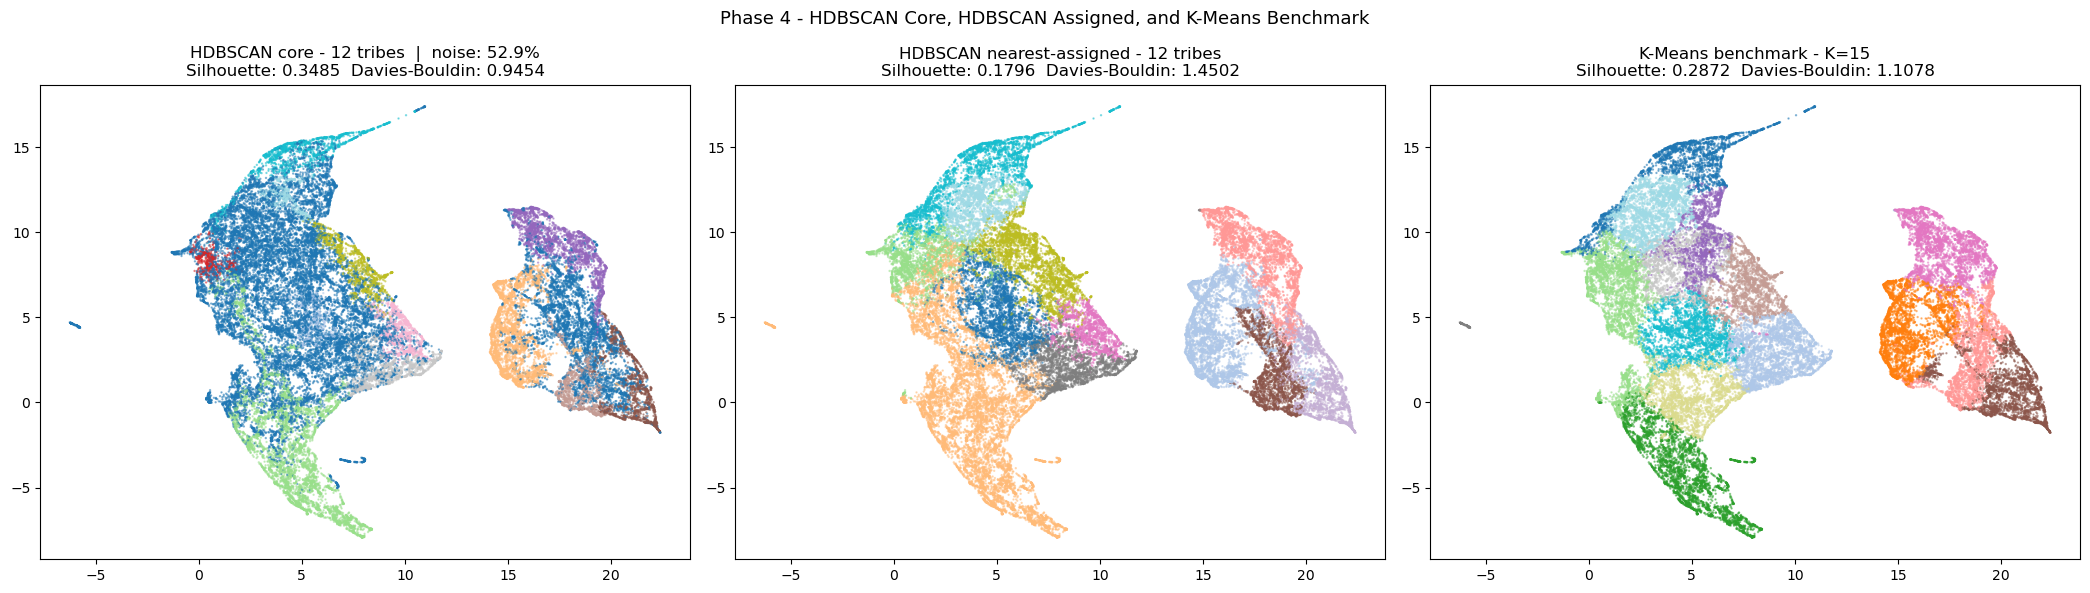

In [26]:
_viz_pd = umap_viz.join(
    hdb_core_labels.select(["cliente", "cluster"]).rename({"cluster": "tribe_hdbscan_core"}),
    on="cliente", how="left"
).join(
    hdb_assigned_labels.select(["cliente", "cluster"]).rename({"cluster": "tribe_hdbscan_assigned"}),
    on="cliente", how="left"
).pipe(
    lambda df: df.join(
        km_labels.select(['cliente', 'cluster']).rename({'cluster': 'tribe_kmeans'}),
        on='cliente', how='left',
    ) if km_labels is not None else df
).sample(n=min(100_000, len(umap_viz)), seed=42).to_pandas()

_n_panels = 3 if (km_labels is not None and 'tribe_kmeans' in _viz_pd.columns) else 2
fig, axes = plt.subplots(1, _n_panels, figsize=(7 * _n_panels, 6))

axes[0].scatter(_viz_pd['x'], _viz_pd['y'],
                c=_viz_pd['tribe_hdbscan_core'], cmap='tab20', s=0.5, alpha=0.5)
axes[0].set_title(f'HDBSCAN core - {n_tribes} tribes  |  noise: {noise_pct:.1f}%\n'
                  f'Silhouette: {results_hdb_core["silhouette"]:.4f}  '
                  f'Davies-Bouldin: {results_hdb_core["davies_bouldin"]:.4f}')

axes[1].scatter(_viz_pd['x'], _viz_pd['y'],
                c=_viz_pd['tribe_hdbscan_assigned'], cmap='tab20', s=0.5, alpha=0.5)
axes[1].set_title(f'HDBSCAN nearest-assigned - {hdb_assigned_labels["cluster"].n_unique()} tribes\n'
                  f'Silhouette: {results_hdb_assigned["silhouette"]:.4f}  '
                  f'Davies-Bouldin: {results_hdb_assigned["davies_bouldin"]:.4f}')

if _n_panels == 3:
    axes[2].scatter(_viz_pd['x'], _viz_pd['y'],
                    c=_viz_pd['tribe_kmeans'], cmap='tab20', s=0.5, alpha=0.5)
    axes[2].set_title(f'K-Means benchmark - K={TARGET_KMEANS_K}\n'
                      f'Silhouette: {results_km["silhouette"]:.4f}  '
                      f'Davies-Bouldin: {results_km["davies_bouldin"]:.4f}')

_title = ('Phase 4 - HDBSCAN Core + Assigned' if _n_panels == 2
          else 'Phase 4 - HDBSCAN Core, HDBSCAN Assigned, and K-Means Benchmark')
plt.suptitle(_title, fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUTS / 'phase4_clustering_comparison.png', dpi=150)
plt.show()

### 3.4.6 How to Read the Clustering Comparison

Use metrics, segment sizes, and commercial profile readability together. Do not select the final segmentation from silhouette alone.

For this project, a lower-silhouette segmentation with strong baby, pet, health, free-from, premium, or other discovered product lifts can be more valuable than a high-silhouette split that is too broad or operationally vague.

<a id="35-selection-log-and-next-experiments"></a>
## 3.5 Selection Log and Next Experiments

Summarise candidate quality before choosing the baseline segmentation. This section is intentionally decision-oriented: it turns the method comparison into a short list of what to keep, what to reject, and what to test next.

In [27]:
# Candidate scorecard for the HDBSCAN-derived solution and fixed-K benchmarks.
# Review this together with the compact/full product-lift tables above.
if "hdb_assigned_profile" not in globals():
    path = DATA_PROCESSED / "tribe_profiles_hdbscan_assigned.parquet"
    if path.exists():
        hdb_assigned_profile = pl.read_parquet(path)
    else:
        raise RuntimeError("No HDBSCAN assigned profiles found. Run Section 3.4.3 first.")

if "kmeans_profile_summaries" not in globals() or not kmeans_profile_summaries:
    kmeans_profile_summaries = {}
    for k in KMEANS_BASELINE_CLUSTERS:
        path = DATA_PROCESSED / f"tribe_profiles_kmeans_k{int(k)}.parquet"
        if path.exists():
            kmeans_profile_summaries[int(k)] = pl.read_parquet(path)


def _round_or_none(value, digits=2):
    if value is None:
        return None
    try:
        if pd.isna(value):
            return None
    except TypeError:
        pass
    return round(float(value), digits)


def _profile_quality_row(candidate, role, profiles, metrics=None, *, original_noise_pct=0.0, assigned_from_noise_pct=0.0):
    metrics = metrics or {}
    sizes = profiles["n_customers"].to_numpy()
    total = sizes.sum()
    size_shares = sizes / total if total else sizes

    theme_lists = profiles["top_themes"].to_list() if "top_themes" in profiles.columns else []
    sector_lists = profiles["top_sectors"].to_list() if "top_sectors" in profiles.columns else []
    nonempty_themes = sum(1 for x in theme_lists if isinstance(x, list) and len(x) > 0)
    nonempty_sectors = sum(1 for x in sector_lists if isinstance(x, list) and len(x) > 0)

    min_share = float(size_shares.min() * 100) if len(size_shares) else None
    max_share = float(size_shares.max() * 100) if len(size_shares) else None
    sil = metrics.get("silhouette")
    noise_for_penalty = original_noise_pct if original_noise_pct is not None else metrics.get("noise_pct", 0.0)
    coverage_adj_sil = None if sil is None else float(sil) * (1 - float(noise_for_penalty or 0) / 100)

    review_note = "review product distinctiveness"
    if assigned_from_noise_pct and assigned_from_noise_pct > 50:
        review_note = "check nearest-assignment confidence"
    elif min_share is not None and min_share < 2:
        review_note = "watch tiny tribes"
    elif max_share is not None and max_share > 35:
        review_note = "watch dominant tribe"

    return {
        "candidate": candidate,
        "role": role,
        "n_clusters": int(metrics.get("n_clusters", profiles.height)),
        "original_hdbscan_noise_pct": _round_or_none(original_noise_pct),
        "assigned_from_noise_pct": _round_or_none(assigned_from_noise_pct),
        "silhouette": _round_or_none(sil, 4),
        "coverage_adj_silhouette": _round_or_none(coverage_adj_sil, 4),
        "davies_bouldin": _round_or_none(metrics.get("davies_bouldin"), 4),
        "min_cluster_share_pct": _round_or_none(min_share),
        "max_cluster_share_pct": _round_or_none(max_share),
        "clusters_with_theme_lift": nonempty_themes,
        "clusters_with_sector_lift": nonempty_sectors,
        "review_note": review_note,
    }


candidate_rows = []
_hdb_noise = results_hdb_core.get("noise_pct") if "results_hdb_core" in globals() else noise_pct if "noise_pct" in globals() else 0.0
_hdb_assigned_noise = float(hdb_assigned_labels["was_hdbscan_noise"].mean() * 100) if "hdb_assigned_labels" in globals() else _hdb_noise
candidate_rows.append(_profile_quality_row(
    "hdbscan_assigned",
    "primary HDBSCAN-derived candidate",
    hdb_assigned_profile,
    results_hdb_assigned if "results_hdb_assigned" in globals() else None,
    original_noise_pct=_hdb_noise,
    assigned_from_noise_pct=_hdb_assigned_noise,
))

for k in sorted(kmeans_profile_summaries):
    profiles_k = kmeans_profile_summaries[k]
    metrics = kmeans_results.filter(pl.col("requested_k") == k).to_dicts() if "kmeans_results" in globals() else []
    metrics = metrics[0] if metrics else {}
    candidate_rows.append(_profile_quality_row(
        f"kmeans_k{k}",
        "fixed-K benchmark only",
        profiles_k,
        metrics,
        original_noise_pct=metrics.get("noise_pct", 0.0),
        assigned_from_noise_pct=0.0,
    ))

candidate_scorecard = pd.DataFrame(candidate_rows)
display(candidate_scorecard)

print("HDBSCAN decision note:")
if "results_hdb_core" in globals():
    print(
        f"Core HDBSCAN discovered {results_hdb_core['n_clusters']} high-density tribes "
        f"with {results_hdb_core['noise_pct']:.1f}% density noise."
    )
print(
    "The assigned version keeps HDBSCAN as the discovery model, labels every customer by nearest core tribe, "
    "and preserves was_hdbscan_noise/assignment_distance for confidence checks."
)
print("K-Means rows are retained only as a diagnostic benchmark because the brief discourages fixed spherical clusters as the final model.")

,candidate,role,n_clusters,original_hdbscan_noise_pct,assigned_from_noise_pct,silhouette,coverage_adj_silhouette,davies_bouldin,min_cluster_share_pct,max_cluster_share_pct,clusters_with_theme_lift,clusters_with_sector_lift,review_note
0,hdbscan_assigned,primary HDBSCAN-derived candidate,12,52.91,52.91,0.1796,0.0846,1.4502,3.83,22.22,12,12,check nearest-assignment confidence
1,kmeans_k8,fixed-K benchmark only,8,0.00,0.00,0.2891,0.2891,1.2438,9.29,17.45,8,8,review product distinctiveness
2,kmeans_k10,fixed-K benchmark only,10,0.00,0.00,0.2923,0.2923,1.1679,7.13,12.79,10,10,review product distinctiveness
3,kmeans_k12,fixed-K benchmark only,12,0.00,0.00,0.2816,0.2816,1.1699,6.02,10.27,12,12,review product distinctiveness
4,kmeans_k15,fixed-K benchmark only,15,0.00,0.00,0.2872,0.2872,1.1078,0.33,9.17,15,15,watch tiny tribes
5,kmeans_k18,fixed-K benchmark only,18,0.00,0.00,0.2689,0.2689,1.1697,3.38,8.42,18,18,review product distinctiveness


HDBSCAN decision note:
Core HDBSCAN discovered 12 high-density tribes with 52.9% density noise.
The assigned version keeps HDBSCAN as the discovery model, labels every customer by nearest core tribe, and preserves was_hdbscan_noise/assignment_distance for confidence checks.
K-Means rows are retained only as a diagnostic benchmark because the brief discourages fixed spherical clusters as the final model.


### 3.5.1 Champion Decision Template

After reviewing the scorecard and profile tables in Section 3.5, record the current champion here.

---

**Configured selection mode:**
`configs/base.yaml -> pipeline.*` may be `auto` or locked to a concrete model.

**Selected representation:**
`SELECTED_VECTOR_SOURCE`, persisted to `outputs/.../model_selection/vector_source_selection.json`.

**Selected reducer:**
`SELECTED_REDUCER`, persisted to `outputs/.../model_selection/reducer_selection.json`.

**Selected clusterer:**
`SELECTED_CLUSTERER`, persisted to `outputs/.../model_selection/clusterer_selection.json`.

**Product-only guardrail:**
Experiment 0 remains product-only unless `hybrid_with_store` or non-zero promo/store/KPI weights are deliberately configured as ablations.

**Why this model wins:** *(fill in after profiling)*
Product/theme lifts are interpretable, tribe sizes are commercially viable, and segments are actionable.

**Known weaknesses:** *(fill in)*
Overlap, fragmentation, generic tribes, high assignment distance, etc.

**Next experiment:**
Change one variable in config, rerun from the relevant force flag, and compare to the persisted selection artifacts.

---